In [3]:
# python
import scdrs
import scanpy as sc
import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats
IPython.display.set_matplotlib_formats = set_matplotlib_formats
sc.set_figure_params(dpi=125)
from anndata import AnnData
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:
# raw替换adata 步骤, 因为有负数
# 只单独运行一次
if True:
    import anndata
    adata = sc.read_h5ad("64_human_adata.h5ad")
    print(adata)
    # 检查 adata.raw 的形状
    print("adata.raw 形状:", adata.raw.shape)
    print("adata.X 形状:", adata.shape)
    
    # 创建新 AnnData 对象，替换 adata.X 为 adata.raw 的表达矩阵
    # 确保 var 与 raw.var 对齐
    if adata.raw.n_vars != adata.n_vars or not all(adata.var.index == adata.raw.var.index):
        print("警告: adata.raw 的基因集与 adata.X 不同，使用 adata.raw 的完整基因集")
        # 创建新 AnnData 对象
        new_adata = anndata.AnnData(
            X=adata.raw.X,         # 使用 adata.raw 的完整基因集 (347437, 33538)
            obs=adata.obs.copy(),  # 复制样本元数据
            var=adata.raw.var.copy(),  # 使用 raw 的基因信息
            obsm=adata.obsm.copy(),    # 复制其他兼容数据
            uns=adata.uns.copy(),      # 复制无结构数据
            obsp=adata.obsp.copy()     # 复制样本间关系
        )
    else:
        print("基因集一致，直接替换 adata.X")
        new_adata = adata.copy()  # 复制原始 AnnData
        new_adata.X = adata.raw.X  # 替换表达矩阵
    
    # 验证新矩阵
    print("新 AnnData:")
    print(new_adata)
    print("新矩阵最小值:", new_adata.X.min())  # 确保非负
    
    # 保存到新文件
    new_adata.write_h5ad("raw_hg.h5ad")
    print("已保存到 raw_hg.h5ad")

AnnData object with n_obs × n_vars = 340232 × 5000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1', 'seurat_clusters', 'condition', 'section', 'condition_withrep', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'harmony_clusters', 'predicted_labels', 'conf_score', 'harmony_clusters_res1', 'dominant_labels', 'dominant_labels_short'
    var: 'var.features', 'var.features.rank'
    uns: 'cluster_highlights_colors', 'dominant_labels_colors', 'dominant_labels_short_colors', 'harmony_clusters_res1', 'harmony_clusters_res1.2', 'harmony_clusters_res1_colors', 'low_conf_micro_colors', 'major_cluster_colors', 'major_clusters_colors', 'neighbors', 'predicted_labels_colors'
    obsm: 'X_harmony', 'X_pca', 'X_tsne.harmony', 'X_umap.harmony'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
adata.raw 形状: (340232, 33538)
adata.X 形状: (340232, 5000)
警告: adata.raw 的基因集与 adata.X 不同，使用 adata.raw 的完整基因集
新 AnnData:
AnnData object with n_o

In [4]:
os.chdir('/biostack/home/suchenyi/scdrs')

adata = sc.read_h5ad("raw_hg.h5ad")
# print(adata)
# AnnData object with n_obs × n_vars = 347437 × 33538
adata.obs


,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.1,seurat_clusters,condition,section,...,S.Score,G2M.Score,Phase,old.ident,harmony_clusters,predicted_labels,conf_score,harmony_clusters_res1,dominant_labels,dominant_labels_short
BA11_C_rep1_AAACCCAAGCGCGTTC,SeuratProject,6464.0,3050,0.355817,1745.0,1150,3,6,BA11_C,BA11,...,-0.017051,-0.009848,G1,3,44,L3-5 RORB MKX DCC,0.999831,82,L3-5 RORB MKX GRIN3A,L3-5
BA11_C_rep1_AAACCCACACCCAATA,SeuratProject,11218.0,4056,0.062400,1866.0,1210,3,6,BA11_C,BA11,...,-0.014367,-0.000450,G1,3,44,L3-5 RORB MKX GRIN3A,0.993635,16,L3-5 RORB MKX GRIN3A,L3-5
BA11_C_rep1_AAACCCACACCCTAGG,SeuratProject,5022.0,2427,0.876145,2152.0,1458,2,1,BA11_C,BA11,...,0.015694,-0.001217,S,2,1,L2-3 CUX2 NTNG1 COL5A2,0.301942,5,L2-3 CUX2 NTNG1 PALMD,L2-3
BA11_C_rep1_AAACCCACAGTGTGCC,SeuratProject,1250.0,905,0.160000,1432.0,905,5,0,BA11_C,BA11,...,-0.014270,-0.009266,G1,5,0,Oligo MOG OPALIN,0.999970,76,Oligo MOG OPALIN,Oligo
BA11_C_rep1_AAACCCACATACCGTA,SeuratProject,503.0,431,0.198807,1193.0,540,13,11,BA11_C,BA11,...,-0.011288,0.010270,G2M,13,3,Micro P2RY12 APBB1IP,0.164314,18,Micro P2RY12 APBB1IP,Micro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BA9_S_rep9_TTTGTCAAGGGATGGG-1,SeuratProject,3297.0,1896,0.030331,2324.0,1754,5,19,BA9_S,BA9,...,-0.009316,-0.020331,G1,5,11,L6 OPRK1 THEMIS RGS6,0.996405,92,L6 OPRK1 THEMIS RGS6,L6
BA9_S_rep9_TTTGTCACATGTCCTC-1,SeuratProject,2001.0,1183,0.149925,1905.0,1151,4,15,BA9_S,BA9,...,0.015956,0.013024,S,4,7,InN VIP HS3ST3B1,0.204977,153,InN VIP SCML4,InN
BA9_S_rep9_TTTGTCAGTAAGTGGC-1,SeuratProject,2388.0,1459,0.376884,2101.0,1406,3,12,BA9_S,BA9,...,0.011092,-0.013264,S,3,4,InN PVALB ANOS1,0.984113,131,InN PVALB ANOS1,InN
BA9_S_rep9_TTTGTCAGTGCAGACA-1,SeuratProject,1357.0,969,0.810612,1414.0,926,9,18,BA9_S,BA9,...,0.001904,0.003998,G2M,9,10,InN LAMP5 ADAMTS20,0.214403,88,InN LAMP5 BMP7,InN


In [5]:
# subset gene sets
import numpy as np
import pandas as pd
df_gs = pd.read_csv("./mdd3.gs", sep="\t", index_col=0)
display(df_gs)
df_gs.index

,GENESET
TRAIT,
mdd,"DCC:9.7012,SGCZ:9.4621,ASTN2:9.1562,SOX5:8.780..."


Index(['mdd'], dtype='object', name='TRAIT')

In [1]:
%%capture
# 没有分区的
# We use scdrs compute-score cli to evaluate disease enrichment to individual cells.
!scdrs compute-score \
     --h5ad-file ./raw_hg.h5ad \
     --h5ad-species human \
     --gs-file ./mdd3.gs \
     --gs-species human \
     --flag-filter-data True \
     --flag-raw-count True \
     --flag-return-ctrl-raw-score False \
     --flag-return-ctrl-norm-score True \
     --out-folder mdd3_analysis/


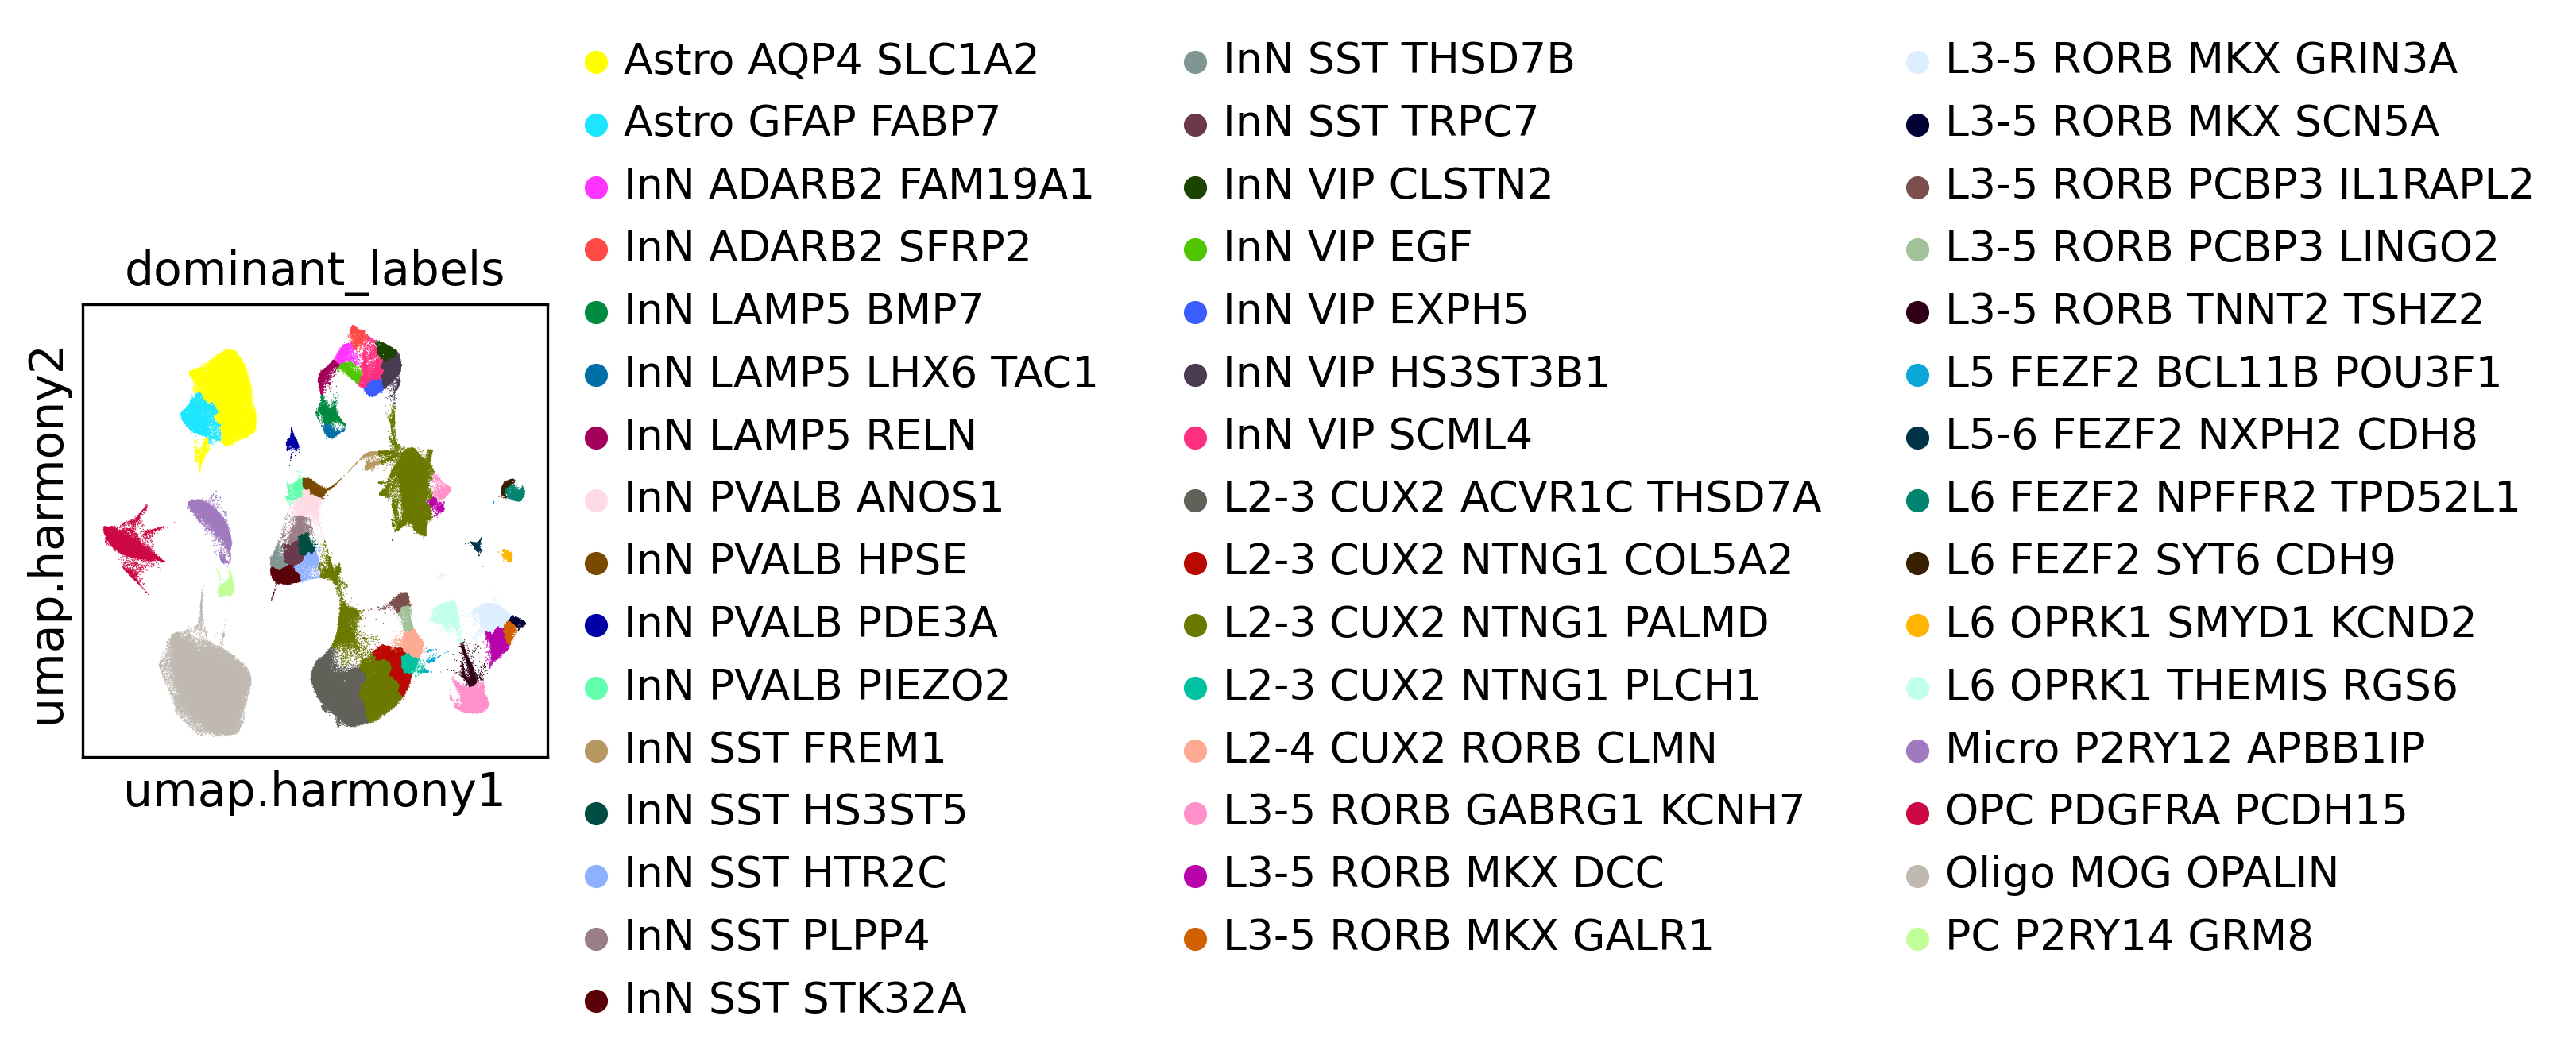

dict_keys(['mdd'])


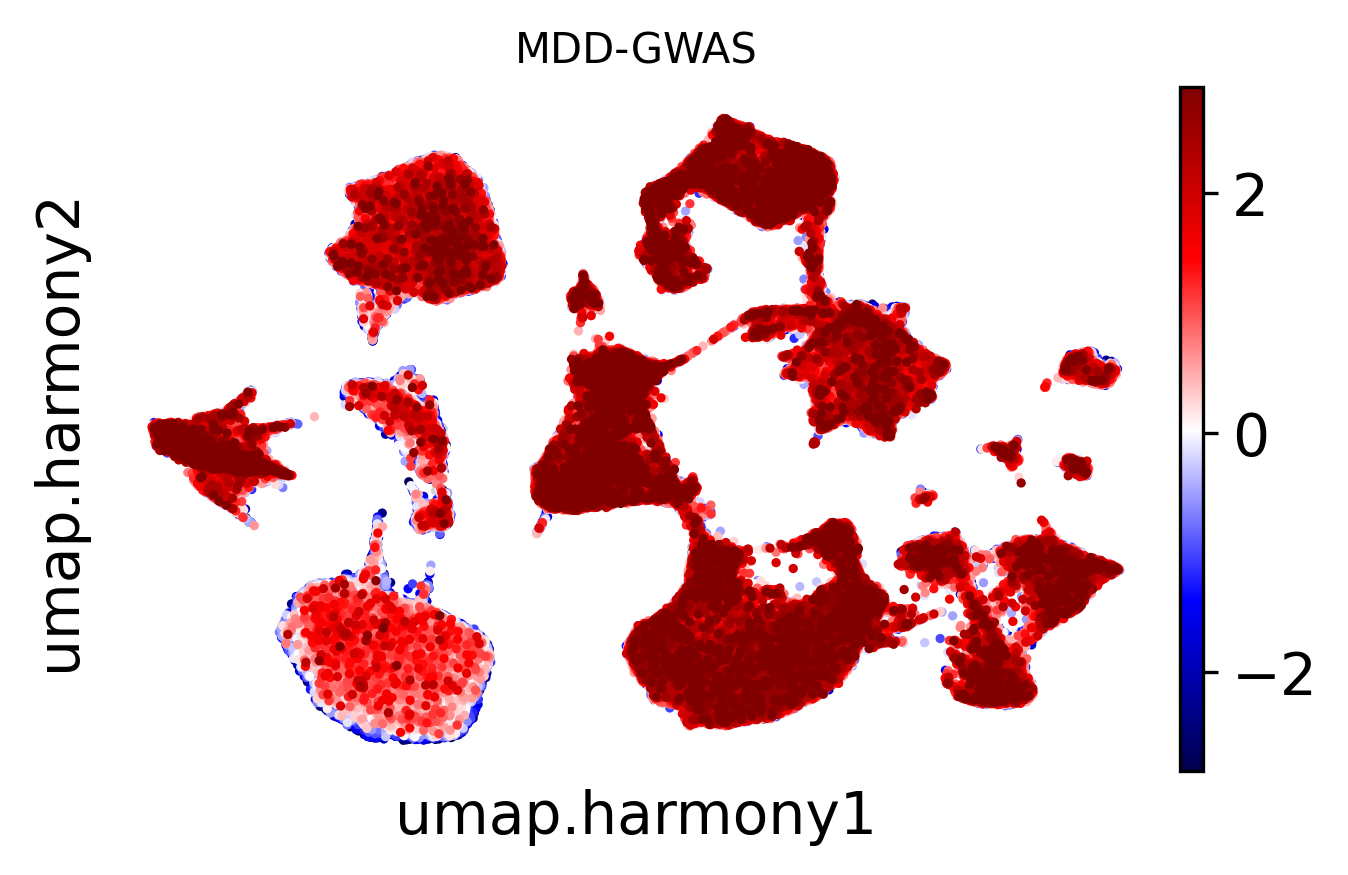

In [34]:
# 没分区的整体结果画图代码
# For an overview of scDRS results, we overlay the computed scDRS disease scores on the UMAP.
dict_score = {
    trait: pd.read_csv(f"mdd3_analysis/{trait}.full_score.gz", sep="\t", index_col=0)
    for trait in df_gs.index
}
# print(dict_score)
for trait in dict_score:
    adata.obs[trait] = dict_score[trait]["norm_score"]
    scores = dict_score[trait]["norm_score"]


sc.set_figure_params(figsize=[2.5, 2.5], dpi=150)
# 图1：condition_withrep
sc.pl.embedding(
    adata,
    "umap.harmony",
    color="dominant_labels",
    ncols=1,
    save="64human_dominant_labels.pdf"
)
plt.close()

print(dict_score.keys())
fig=sc.pl.embedding(
    adata,
    "umap.harmony",
    color=list(dict_score.keys()),
    color_map="seismic",
    vmin=np.percentile(scores, 1),
    vmax=np.percentile(scores, 99),
    s=20,
    return_fig=True
)
fig.set_size_inches(5, 3)
    # 修改标题
ax = fig.axes[0]
ax.set_title("MDD-GWAS", fontsize=10)

    # 去掉边框（spines）
for spine in ax.spines.values():
    spine.set_visible(False)
fig.savefig( "64human_MDD_deepblue_bar.pdf", dpi=300)
plt.show()

mdd: vmin=-2.83, vmax=2.88


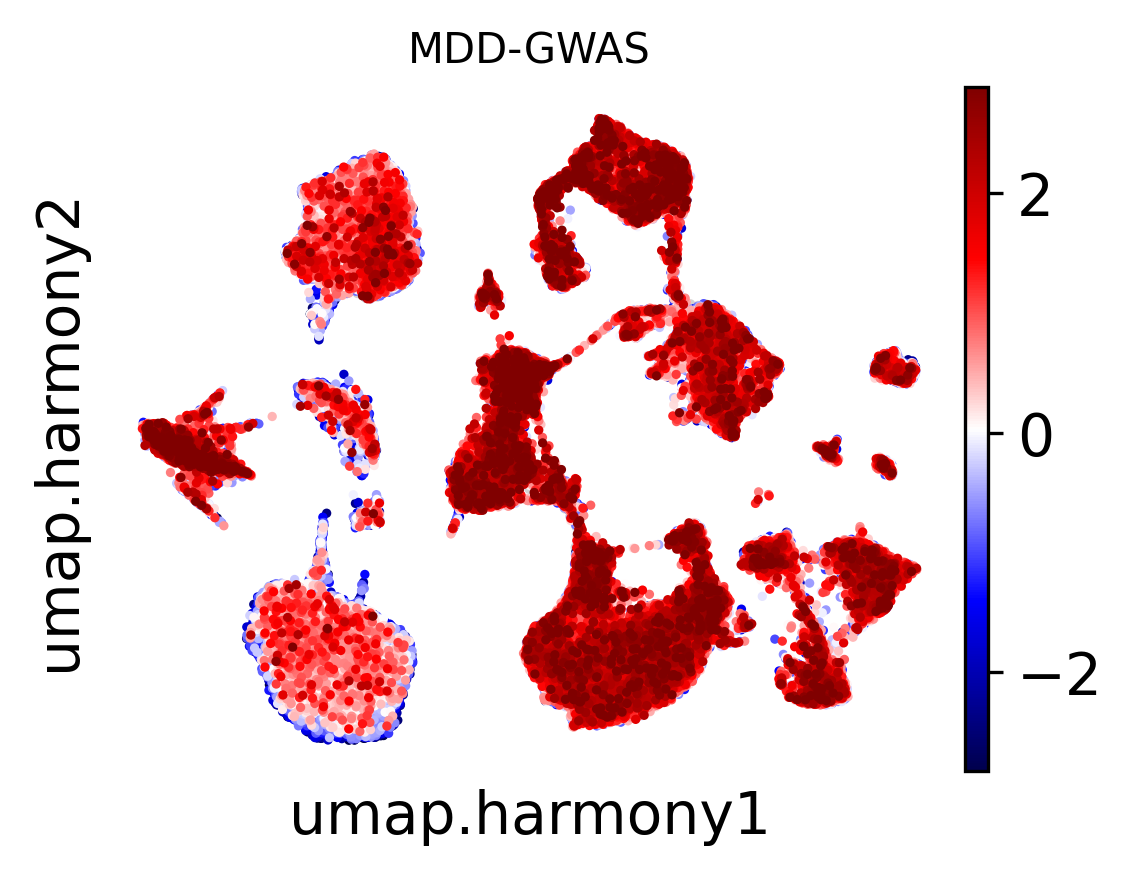

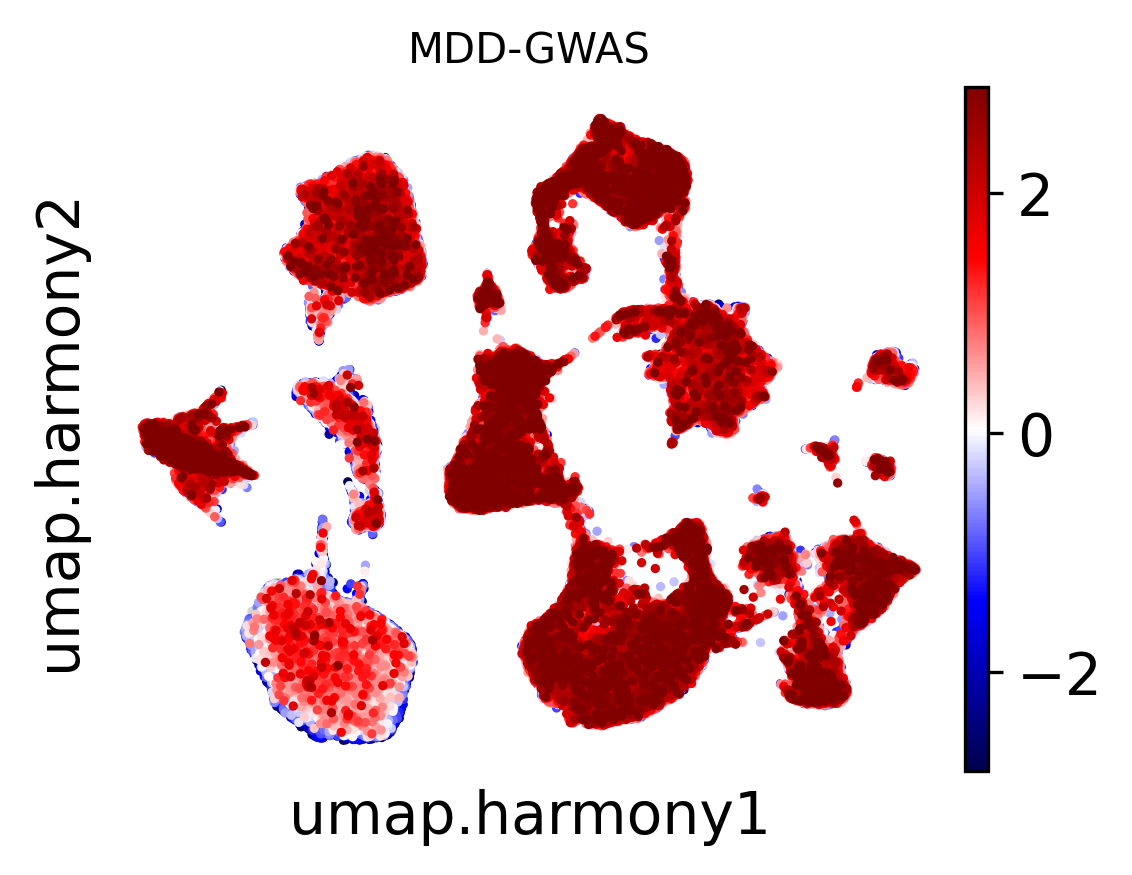

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

# 设置绘图参数
sc.set_figure_params(figsize=[2.5, 2.5], dpi=150)

# Step 1：统一获取一个 trait 的 score 用于计算色条范围
main_trait = list(dict_score.keys())[0]
scores = dict_score[main_trait]["norm_score"]
vmin = np.percentile(scores, 1)
vmax = np.percentile(scores, 99)
print(f"{main_trait}: vmin={vmin:.2f}, vmax={vmax:.2f}")

# Step 2：分别筛选 S / C 子集
adata_S = adata[adata.obs["condition"].str.contains("S")].copy()
adata_C = adata[adata.obs["condition"].str.contains("C")].copy()

# Step 3：绘制每个 trait 的 S 图
for trait in dict_score.keys():
    adata_S.obs[trait] = dict_score[trait]["norm_score"]

    fig = sc.pl.embedding(
        adata_S,
        basis="umap.harmony",
        color=trait,
        color_map="seismic",
        vmin=vmin,
        vmax=vmax,
        s=20,
        show=True,
        return_fig=True
    )

    fig.set_size_inches(4, 3)
    ax = fig.axes[0]
    ax.set_title("MDD-GWAS", fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.savefig(f"64human_MDD_S_{trait}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.3)
    #plt.close(fig)

# Step 4：绘制每个 trait 的 C 图
for trait in dict_score.keys():
    adata_C.obs[trait] = dict_score[trait]["norm_score"]

    fig = sc.pl.embedding(
        adata_C,
        basis="umap.harmony",
        color=trait,
        color_map="seismic",
        vmin=vmin,
        vmax=vmax,
        s=20,
        show=True,
        return_fig=True
    )

    fig.set_size_inches(4, 3)
    ax = fig.axes[0]
    ax.set_title("MDD-GWAS", fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.savefig(f"64human_MDD_C_{trait}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.3)
    #plt.close(fig)


In [6]:
dict_score = {
    trait: pd.read_csv(f"mdd3_analysis/{trait}.full_score.gz", sep="\t", index_col=0)
    for trait in df_gs.index
}
for trait in dict_score:
    adata.obs[trait] = dict_score[trait]["norm_score"]
    scores = dict_score[trait]["norm_score"]
    adata.obs

In [15]:
%%capture
# 整体下游分析
#样本分类
for trait in ["mdd"]:
    !scdrs perform-downstream \
        --h5ad-file raw_hg.h5ad \
        --score-file mdd3_analysis/{trait}.full_score.gz \
        --out-folder  mdd3_analysis/\
        --group-analysis "condition" \
        --flag-filter-data True \
        --flag-raw-count True
#细胞类型分类
for trait in ["mdd"]:
    !scdrs perform-downstream \
        --h5ad-file raw_hg.h5ad \
        --score-file mdd3_analysis/{trait}.full_score.gz \
        --out-folder  mdd3_analysis/\
        --group-analysis "dominant_labels" \
        --flag-filter-data True \
        --flag-raw-count True
for trait in ["mdd"]:
    !scdrs perform-downstream \
        --h5ad-file raw_hg.h5ad \
        --score-file mdd3_analysis/{trait}.full_score.gz \
        --out-folder  mdd3_analysis/\
        --group-analysis "dominant_labels_short" \
        --flag-filter-data True \
        --flag-raw-count True

In [19]:
#脑区分类
for trait in ["mdd"]:
    !scdrs perform-downstream \
        --h5ad-file raw_hg.h5ad \
        --score-file mdd3_analysis/{trait}.full_score.gz \
        --out-folder  mdd3_analysis/\
        --group-analysis "section" \
        --flag-filter-data True \
        --flag-raw-count True

******************************************************************************
* Single-cell disease relevance score (scDRS)
* Version 1.0.3
* Martin Jinye Zhang and Kangcheng Hou
* HSPH / Broad Institute / UCLA
* MIT License
******************************************************************************
Call: scdrs perform-downstream \
--h5ad-file raw_hg.h5ad \
--score-file mdd3_analysis/mdd.full_score.gz \
--out-folder mdd3_analysis/ \
--group-analysis section\
--flag-filter-data True \
--flag-raw-count True \
--min-genes 250 \
--min-cells 50 \
--knn-n-neighbors 15 \
--knn-n-pcs 20

--h5ad-file loaded: n_cell=337589, n_gene=27380 (sys_time=241.5s)
First 3 cells: ['BA11_C_rep1_AAACCCAAGCGCGTTC', 'BA11_C_rep1_AAACCCACACCCAATA', 'BA11_C_rep1_AAACCCACACCCTAGG']
First 5 genes: ['MIR1302-2HG', 'AL627309.1', 'AC114498.1', 'AL669831.5', 'FAM87B']
Score file folder: mdd3_analysis
Find 1 score files: mdd.full_score.gz
--score-file loaded: n_trait=1 (sys_time=301.1s)
Print info for the first tra

In [8]:
# scDRS group-level statistics for MDD
!cat mdd3_analysis/mdd.scdrs_group.dominant_labels | column -t -s $'\t'
!cat mdd3_analysis/mdd.scdrs_group.dominant_labels_short | column -t -s $'\t'
!cat mdd3_analysis/mdd.scdrs_group.condition | column -t -s $'\t'
!cat mdd3_analysis/mdd.scdrs_group.condition_withrep| column -t -s $'\t'

group                     n_cell   n_ctrl  assoc_mcp    assoc_mcz    hetero_mcp   hetero_mcz   n_fdr_0.05  n_fdr_0.1  n_fdr_0.2
Astro AQP4 SLC1A2         33112.0  1000.0  0.7152847    -0.57017004  0.000999001  4.871458     0.0         1.0        9.0
Astro GFAP FABP7          5405.0   1000.0  0.62837166   -0.35276026  0.53946054   -0.14538415  0.0         0.0        2.0
InN ADARB2 FAM19A1        2352.0   1000.0  0.001998002  3.6571445    0.068931065  1.5355636    0.0         2.0        13.0
InN ADARB2 SFRP2          2154.0   1000.0  0.000999001  3.9656322    0.22077923   0.63097656   0.0         0.0        10.0
InN LAMP5 BMP7            4103.0   1000.0  0.012987013  2.3206317    0.25274727   0.4255567    0.0         0.0        9.0
InN LAMP5 LHX6 TAC1       1650.0   1000.0  0.03696304   1.8777028    0.7692308    -0.71162766  0.0         0.0        0.0
InN LAMP5 RELN            2729.0   1000.0  0.000999001  3.9317958    0.3046953    0.41923407   0.0         0.0        15.0
InN PVALB ANOS1

0.000999001 0.26223776225 0.93406594
mdd 0.0 2.0


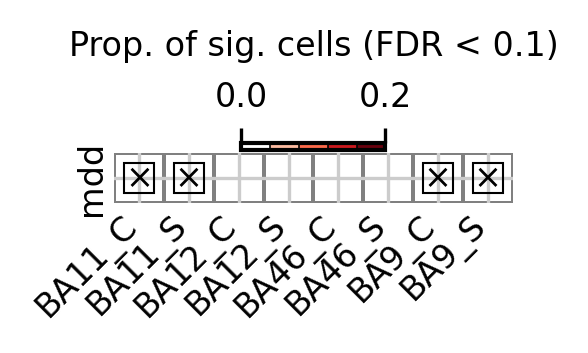

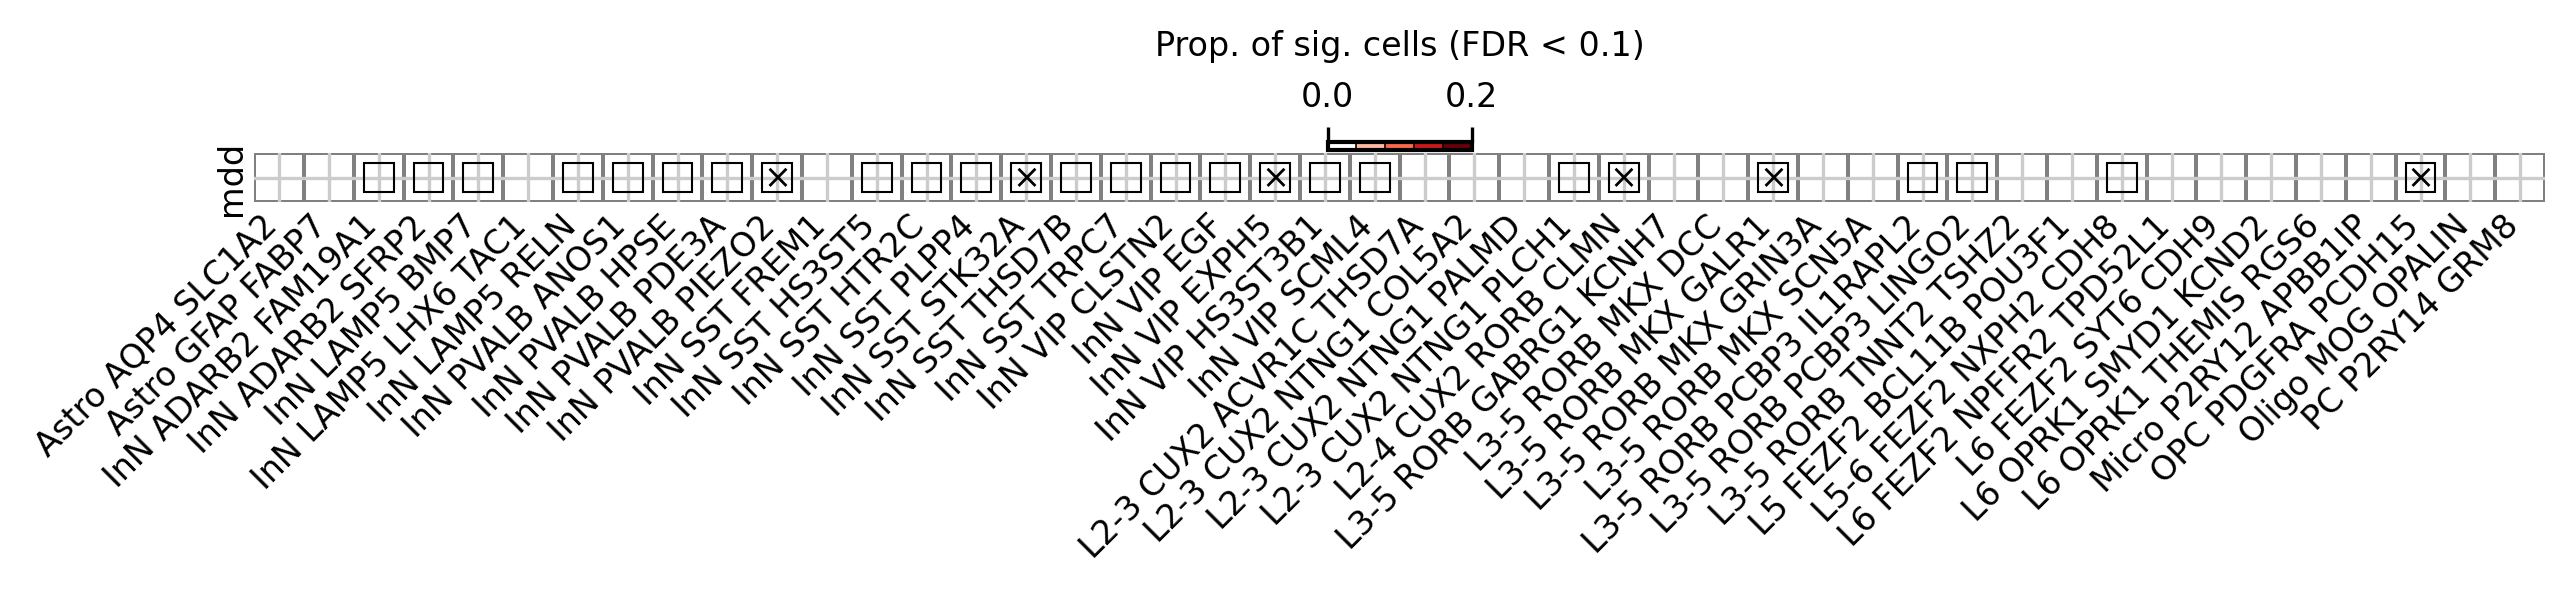

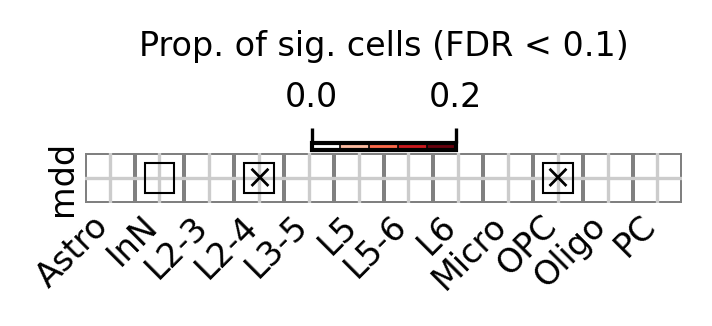

In [39]:
import numpy as np
dict_df_stats = {
    trait: pd.read_csv(f"mdd3_analysis/{trait}.scdrs_group.condition", sep="\t", index_col=0)
    for trait in ["mdd"]
}
# print(dict_df_stats.items())
fig, ax = scdrs.util.plot_group_stats(
    dict_df_stats,
    plot_kws={
        "vmin":0,
        "vmax":1,
        "cb_fraction":0.12
    }
)
vals = np.concatenate([df['assoc_mcp'].values for df in dict_df_stats.values()])
print(vals.min(), vals.mean(), vals.max())
# 0.000999001 0.26223776225 0.93406594


dict_df_stats = {
    trait: pd.read_csv(f"mdd3_analysis/{trait}.scdrs_group.dominant_labels", sep="\t", index_col=0)
    for trait in ["mdd"]
}
# print(dict_df_stats.items())
fig, ax = scdrs.util.plot_group_stats(
    dict_df_stats,
    plot_kws={
        "vmax": 0.2,
        "cb_fraction":0.12
    }
)

dict_df_stats = {
    trait: pd.read_csv(f"mdd3_analysis/{trait}.scdrs_group.dominant_labels_short", sep="\t", index_col=0)
    for trait in ["mdd"]
}
# print(dict_df_stats.items())
fig, ax = scdrs.util.plot_group_stats(
    dict_df_stats,
    plot_kws={
        "vmax": 0.2,
        "cb_fraction":0.12
    }
)

# check the raw counts
for trait, df in dict_df_stats.items():
    print(trait,
          (df['n_fdr_0.05']).min(),
          (df['n_fdr_0.05']).max())


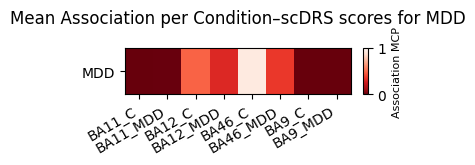

In [52]:
#和上一步一样，只是换一个分组
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置要画的性状
traits = ["mdd"]

region_map = {
    "BA11_C": "BA11_C",
    "BA11_S": "BA11_MDD",
    "BA12_C": "BA12_C",
    "BA12_S": "BA12_MDD",
    "BA46_C": "BA46_C",
    "BA46_S": "BA46_MDD",
    "BA9_C": "BA9_C",
    "BA9_S": "BA9_MDD"
}

# 读取数据
dict_df_stats = {
    trait: pd.read_csv(
        f"mdd3_analysis/{trait}.scdrs_group.condition",
        sep="\t",
        index_col=0
    )
    for trait in traits
}


# 样本名称
samples = list(dict_df_stats[traits[0]].index)

# 创建assoc_mcp矩阵
assoc_matrix = np.array([
    dict_df_stats[trait].loc[samples, "assoc_mcp"].values
    for trait in traits
])

# 显著性矩阵（方块）
#sig_assoc = np.array([
#    (dict_df_stats[trait].loc[samples, "n_fdr_0.05"] > 0).values
#    for trait in traits
#])

# 异质性矩阵（叉号）
#sig_hetero = np.array([
#    (dict_df_stats[trait].loc[samples, "hetero_mcp"] < 0.05).values
#    for trait in traits
#])

# 画图
fig, ax = plt.subplots(figsize=(len(samples)*0.4, len(traits)*0.6))

im = ax.imshow(
    assoc_matrix,
    cmap="Reds_r",
    vmin=0,
    vmax=1,
    aspect="auto"
)

# 坐标轴
ax.set_xticks(np.arange(len(samples)))
x_labels = [region_map.get(sample, sample) for sample in samples]
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_yticks(np.arange(len(traits)))
ax.set_yticklabels(["MDD"])

# 在显著位置加方块
#只要有 ≥1 个基因在该 group 里通过 FDR<0.05，就画一个黑色方块
#for i in range(len(traits)):
#    for j in range(len(samples)):
#        if sig_assoc[i, j]:
#            ax.scatter(j, i, marker="s", facecolors="none", edgecolors="black", s=60, linewidths=1.5)

# 在显著异质性位置加叉号
#for i in range(len(traits)):
#    for j in range(len(samples)):
#        if sig_hetero[i, j]:
#            ax.scatter(j, i, marker="x", color="black", s=50, linewidths=1.5)

# 色条
cbar = fig.colorbar(im, ax=ax, fraction=0.04,aspect=10)
cbar.set_label("Association MCP", fontsize=8)

# 标题
ax.set_title("Mean Association per Condition–scDRS scores for MDD", fontsize=12,pad=18)
fig.savefig("20250930mdd3-figures/2.1dominant_labels–MDD Association Heatmap.pdf", dpi=300,bbox_inches="tight")
plt.show()


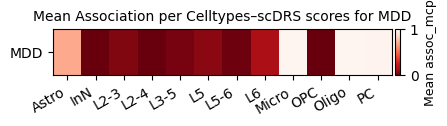

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置要画的性状
traits = ["mdd"]

# 读取数据
dict_df_stats = {
    trait: pd.read_csv(
        f"mdd3_analysis/{trait}.scdrs_group.dominant_labels_short",
        sep="\t",
        index_col=0
    )
    for trait in traits
}
region_map = {
    "BA11_C": "BA11_C",
    "BA11_S": "BA11_MDD",
    "BA12_C": "BA12_C",
    "BA12_S": "BA12_MDD",
    "BA46_C": "BA46_C",
    "BA46_S": "BA46_MDD",
    "BA9_C": "BA9_C",
    "BA9_S": "BA9_MDD"
}

# 样本名称
samples = list(dict_df_stats[traits[0]].index)


# 创建assoc_mcp矩阵
assoc_matrix = np.array([
    dict_df_stats[trait].loc[samples, "assoc_mcp"].values
    for trait in traits
])


# 画图
fig, ax = plt.subplots(figsize=(len(samples)*0.4, len(traits)*0.6))

im = ax.imshow(
    assoc_matrix,
    cmap="Reds_r",
    vmin=0,
    vmax=1,
    aspect="auto"
)

# 坐标轴
ax.set_xticks(np.arange(len(samples)))
x_labels = [region_map.get(sample, sample) for sample in samples]
ax.set_xticklabels(x_labels, rotation=30, ha="right",fontsize=10)
ax.set_yticks(np.arange(len(traits)))
ax.set_yticklabels(["MDD"],fontsize=10)

# 色条
cbar = fig.colorbar(im, ax=ax, fraction=0.08, pad=0.01,aspect=10)
cbar.set_label("Mean assoc_mcp", fontsize=9)


# 标题
ax.set_title("Mean Association per Celltypes–scDRS scores for MDD", fontsize=10)

# 保存
fig.savefig("20250930mdd3-figures/1.2dominant_label scDRS_MDD_GWAS_Association_Heatmap.pdf", dpi=300, bbox_inches="tight")

plt.show()


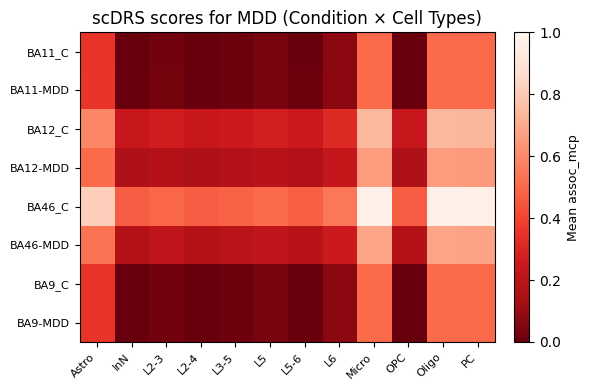

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取condition文件
df_condition = pd.read_csv(
    "mdd3_analysis/mdd.scdrs_group.condition",
    sep="\t",
    index_col=0
)

# 读取dominant_labels_short文件
df_labels = pd.read_csv(
    "mdd3_analysis/mdd.scdrs_group.dominant_labels_short",
    sep="\t",
    index_col=0
)

# 行标签
rows = df_condition.index.tolist()
# 列标签
cols = df_labels.index.tolist()

# 创建值矩阵 (assoc_mcp平均)
heatmap_values = pd.DataFrame(
    np.nan,
    index=rows,
    columns=cols
)

# 创建显著性矩阵
sig_assoc = pd.DataFrame(
    False,
    index=rows,
    columns=cols
)

sig_hetero = pd.DataFrame(
    False,
    index=rows,
    columns=cols
)

# 填充矩阵
for r in rows:
    for c in cols:
        # assoc_mcp平均
        v = (
            df_condition.loc[r, "assoc_mcp"]
            + df_labels.loc[c, "assoc_mcp"]
        ) / 2
        heatmap_values.loc[r, c] = v
        
        # 关联显著性：任一方n_fdr_0.05>0
        assoc_cond = df_condition.loc[r, "n_fdr_0.05"] >0
        assoc_label = df_labels.loc[c, "n_fdr_0.05"] >0
        sig_assoc.loc[r, c] = assoc_cond or assoc_label
        
        # 异质性显著性：任一方hetero_mcp<0.05
        hetero_cond = df_condition.loc[r, "hetero_mcp"] <0.05
        hetero_label = df_labels.loc[c, "hetero_mcp"] <0.05
        sig_hetero.loc[r, c] = hetero_cond or hetero_label

# 绘图
fig, ax = plt.subplots(figsize=(len(cols)*0.5, len(rows)*0.5))

im = ax.imshow(
    heatmap_values.values,
    cmap="Reds_r",
    vmin=0,
    vmax=1,
    aspect="auto"
)

# 坐标轴
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(np.arange(len(rows)))
# 把_S改为-MDD
yticklabels = [x.replace("_S", "-MDD") for x in rows]
ax.set_yticklabels(yticklabels, fontsize=8)


# 色条
cbar = fig.colorbar(im, ax=ax, fraction=0.08, pad=0.04)
cbar.set_label("Mean assoc_mcp", fontsize=9)

# 标题
ax.set_title("scDRS scores for MDD (Condition × Cell Types)", fontsize=12)

# 调整布局
fig.tight_layout()

# 保存
fig.savefig("20250930mdd3-figures/3.1merged_heatmap_MDD_with_significance.pdf", dpi=300, bbox_inches="tight")

plt.show()


In [29]:
# subset gene sets
import numpy as np
import pandas as pd
df_gs = pd.read_csv("./mdd3.gs", sep="\t", index_col=0)
display(df_gs)
df_gs.index
!ls -lh adata_BA_celltype.h5ad


,GENESET
TRAIT,
mdd,"DCC:9.7012,SGCZ:9.4621,ASTN2:9.1562,SOX5:8.780..."


-rw-rw-r-- 1 suchenyi suchenyi 8.0G Jul 11 18:10 adata_BA_celltype.h5ad


In [31]:
#这里是为了后面画BA×celltype的热图，所以把BA×celltype的每个组合作为下游分析的分类依据进行下游分析
#这里输入的h5ad文件只是在原来的raw_hg.h5ad上新建了一列BA_celltype，其实就是每行的section和dominant_labels(或dominant_labels_short)组合
#当然还有condition和dominant_labels(或dominant_labels_short)组合，一共四组
!scdrs perform-downstream \
    --h5ad-file adata_BA_celltype.h5ad \
    --score-file mdd3_analysis/mdd.full_score.gz \
    --group-analysis "BA_celltype" \
    --flag-filter-data False \
    --flag-raw-count True \
    --out-folder mdd3_analysis/


******************************************************************************
* Single-cell disease relevance score (scDRS)
* Version 1.0.3
* Martin Jinye Zhang and Kangcheng Hou
* HSPH / Broad Institute / UCLA
* MIT License
******************************************************************************
Call: scdrs perform-downstream \
--h5ad-file adata_BA_celltype.h5ad \
--score-file mdd3_analysis/mdd.full_score.gz \
--out-folder mdd3_analysis/ \
--group-analysis BA_celltype\
--flag-filter-data False \
--flag-raw-count True \
--min-genes 250 \
--min-cells 50 \
--knn-n-neighbors 15 \
--knn-n-pcs 20

--h5ad-file loaded: n_cell=340232, n_gene=33538 (sys_time=76.7s)
First 3 cells: ['BA11_C_rep1_AAACCCAAGCGCGTTC', 'BA11_C_rep1_AAACCCACACCCAATA', 'BA11_C_rep1_AAACCCACACCCTAGG']
First 5 genes: ['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3']
Score file folder: mdd3_analysis
Find 1 score files: mdd.full_score.gz
--score-file loaded: n_trait=1 (sys_time=131.9s)
Print info for th

In [7]:
# scDRS group-level statistics for MDD
!cat mdd3_analysis/mdd.scdrs_group.section_celltype | column -t -s $'\t'

group         n_cell   n_ctrl  assoc_mcp    assoc_mcz     hetero_mcp   hetero_mcz    n_fdr_0.05  n_fdr_0.1  n_fdr_0.2
BA11_C&Astro  23160.0  1000.0  0.7172827    -0.58592767   0.006993007  3.9086034     0.0         0.0        3.0
BA11_C&InN    33795.0  1000.0  0.000999001  3.7435083     0.34065935   0.13796088    0.0         9.0        124.0
BA11_C&L2-3   48400.0  1000.0  0.0959041    1.3224301     0.0999001    1.3031067     0.0         3.0        30.0
BA11_C&L2-4   2437.0   1000.0  0.011988012  2.4192433     0.064935066  1.573974      0.0         0.0        2.0
BA11_C&L3-5   20652.0  1000.0  0.051948052  1.6263466     0.075924076  1.5409194     0.0         1.0        16.0
BA11_C&L5     229.0    1000.0  0.0989011    1.2870252     0.5334665    -0.18987444   0.0         0.0        0.0
BA11_C&L5-6   618.0    1000.0  0.08691309   1.4050996     0.20779221   0.8268667     0.0         0.0        0.0
BA11_C&L6     5109.0   1000.0  0.27072927   0.62855244    0.068931065  1.6262778     0.0      

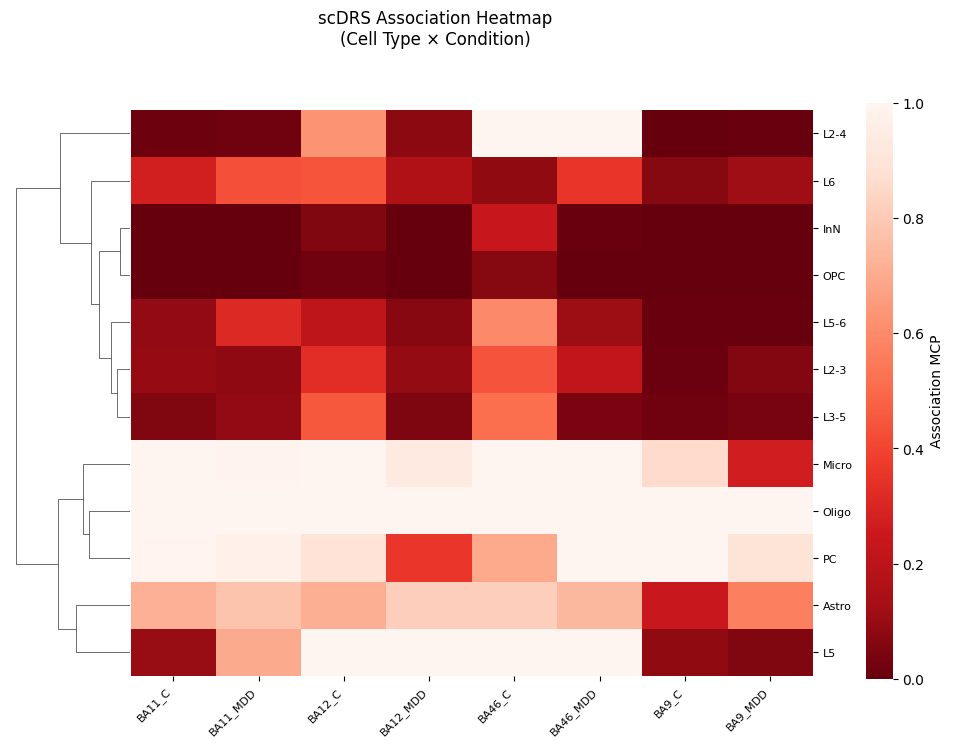

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取数据
df = pd.read_csv(
    "mdd3_analysis/mdd.scdrs_group.section_celltype",
    sep="\t"
)

# 2. 解析 group 列，拆分出 region 和 celltype
df["region"] = df["group"].str.split("&").str[0]
df["celltype"] = df["group"].str.split("&").str[1]

# 检查是否有无法解析的行
if df["celltype"].isna().any():
    print("存在无法解析的 group 行，已剔除")
    df = df[~df["celltype"].isna()]

# 3. 提取唯一脑区和细胞类型
regions = sorted(df["region"].unique())
celltypes = sorted(df["celltype"].unique())

# 4. 创建矩阵 (行=celltype, 列=region)
assoc_matrix = np.full((len(celltypes), len(regions)), np.nan)

# 5. 填充矩阵
for idx, row in df.iterrows():
    i = celltypes.index(row["celltype"])
    j = regions.index(row["region"])
    assoc_matrix[i, j] = row["assoc_mcp"]

# 6. 转为 DataFrame，方便 clustermap
df_assoc = pd.DataFrame(
    assoc_matrix,
    index=celltypes,
    columns=regions
)

region_map = {
    "BA11_C": "BA11_C",
    "BA11_S": "BA11_MDD",
    "BA12_C": "BA12_C",
    "BA12_S": "BA12_MDD",
    "BA46_C": "BA46_C",
    "BA46_S": "BA46_MDD",
    "BA9_C": "BA9_C",
    "BA9_S": "BA9_MDD"
}
df_assoc = df_assoc.rename(columns=region_map)

# 7. 检查并处理 NaN / inf
df_assoc = df_assoc.replace([np.inf, -np.inf], np.nan)  # 先把 inf 转成 NaN
df_assoc = df_assoc.fillna(1.0)  # 用 1.0 填充 NaN（最弱关联）
# 你也可以选择 fillna(0.5) 或者 df_assoc.mean().mean()

# 8. 聚类热图
g = sns.clustermap(
    df_assoc,
    cmap="Reds_r",
    vmin=0,
    vmax=1,
    figsize=(len(regions)*0.6+4, len(celltypes)*0.6),
    row_cluster=True,   # 对 celltype 聚类
    col_cluster=False,   # 对 region 不聚类
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.15),
    cbar_pos=(0.99, 0.05, 0.03, 0.8),  # 调整色条位置
    cbar_kws={"label": "Association MCP"}
)

# 9. 标题
g.fig.suptitle(
    "scDRS Association Heatmap\n(Cell Type × Condition)",
    fontsize=12
)

# 10. 美化标签
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=8
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=8
)

# 11. 保存和展示
g.savefig("20250930mdd3-figures/5.1_ct×region_heatmap_clustered.pdf", dpi=300, format='pdf')
plt.show()


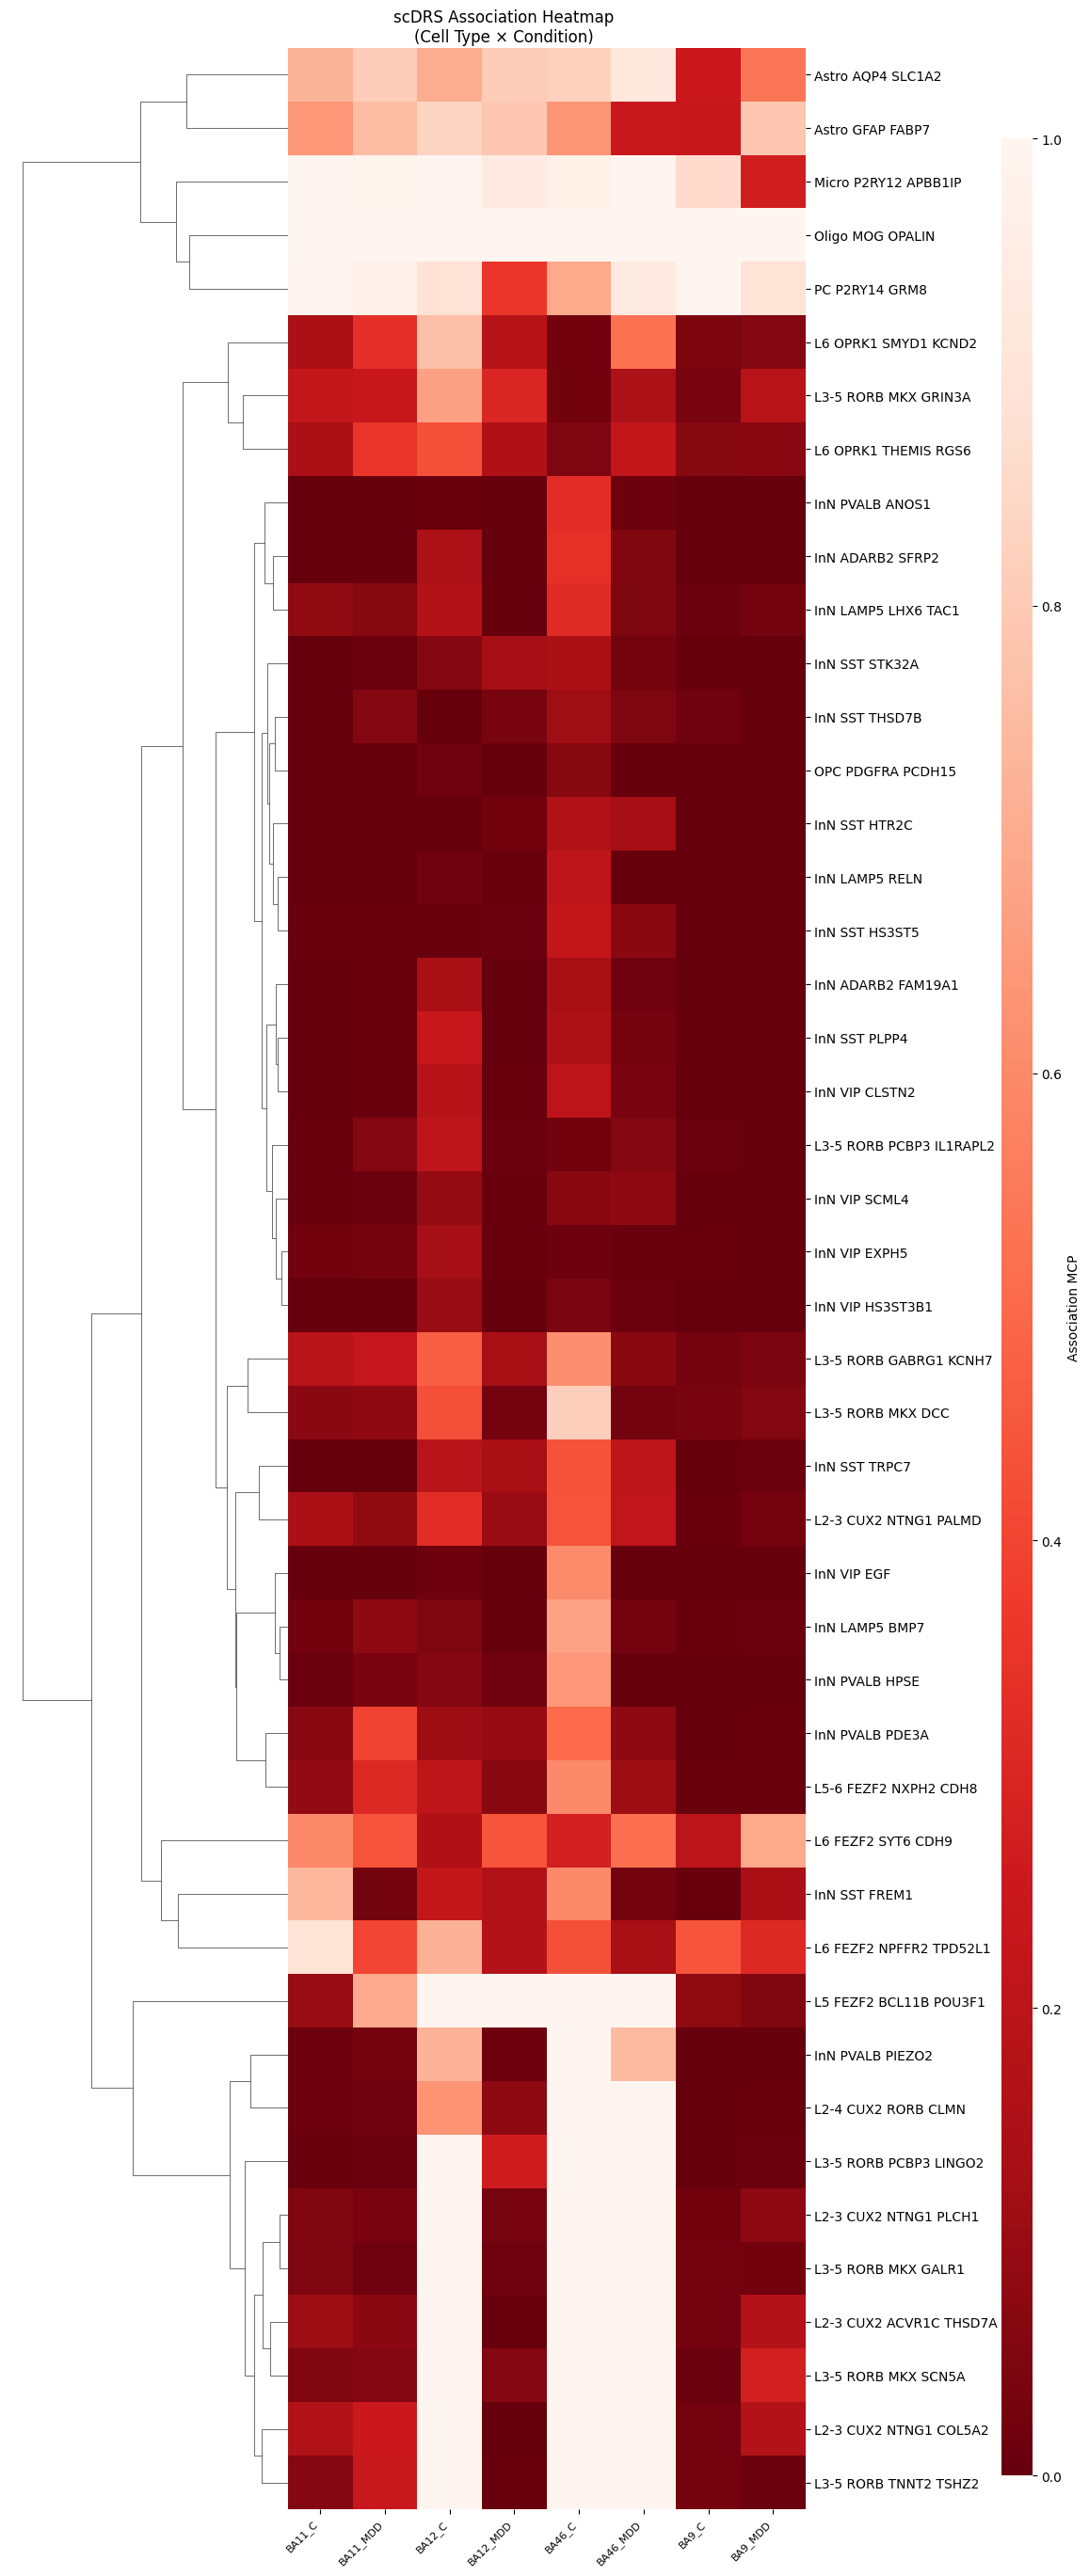

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取数据
df = pd.read_csv(
    "mdd3_analysis/mdd.scdrs_group.cond_dominant",
    sep="\t"
)

# 2. 解析 group 列，拆分出 region 和 celltype
df["region"] = df["group"].str.split("&").str[0]
df["celltype"] = df["group"].str.split("&").str[1]

# 检查是否有无法解析的行
if df["celltype"].isna().any():
    print("存在无法解析的 group 行，已剔除")
    df = df[~df["celltype"].isna()]

# 3. 提取唯一脑区和细胞类型
regions = sorted(df["region"].unique())
celltypes = sorted(df["celltype"].unique())

# 4. 创建矩阵 (行=celltype, 列=region)
assoc_matrix = np.full((len(celltypes), len(regions)), np.nan)

# 5. 填充矩阵
for idx, row in df.iterrows():
    i = celltypes.index(row["celltype"])
    j = regions.index(row["region"])
    assoc_matrix[i, j] = row["assoc_mcp"]

# 6. 转为 DataFrame，方便 clustermap
df_assoc = pd.DataFrame(
    assoc_matrix,
    index=celltypes,
    columns=regions
)

region_map = {
    "BA11_C": "BA11_C",
    "BA11_S": "BA11_MDD",
    "BA12_C": "BA12_C",
    "BA12_S": "BA12_MDD",
    "BA46_C": "BA46_C",
    "BA46_S": "BA46_MDD",
    "BA9_C": "BA9_C",
    "BA9_S": "BA9_MDD"
}
df_assoc = df_assoc.rename(columns=region_map)

# 7. 检查并处理 NaN / inf
df_assoc = df_assoc.replace([np.inf, -np.inf], np.nan)  # 先把 inf 转成 NaN
df_assoc = df_assoc.fillna(1.0)  # 用 1.0 填充 NaN（最弱关联）

# 8. 聚类热图
g = sns.clustermap(
    df_assoc,
    cmap="Reds_r",
    vmin=0,
    vmax=1,
    figsize=(len(regions)*0.6+6, len(celltypes)*0.6),
    row_cluster=True,   # 对 celltype 聚类
    col_cluster=False,   # 对 region 聚类
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.35,0.01),
    cbar_pos=(0.99, 0.05, 0.03, 0.9),  # 调整色条位置
    cbar_kws={"label": "Association MCP"}
)

# 9. 标题
g.fig.suptitle(
    "scDRS Association Heatmap\n(Cell Type × Condition)",
    fontsize=12,
    y=1
)

# 10. 美化标签
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=8
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=10
)

# 11. 保存和展示
g.savefig("20250930mdd3-figures/5.2ct×condition_merged_heatmap_MDD_with_significance.pdf", dpi=300, format='pdf')
plt.show()


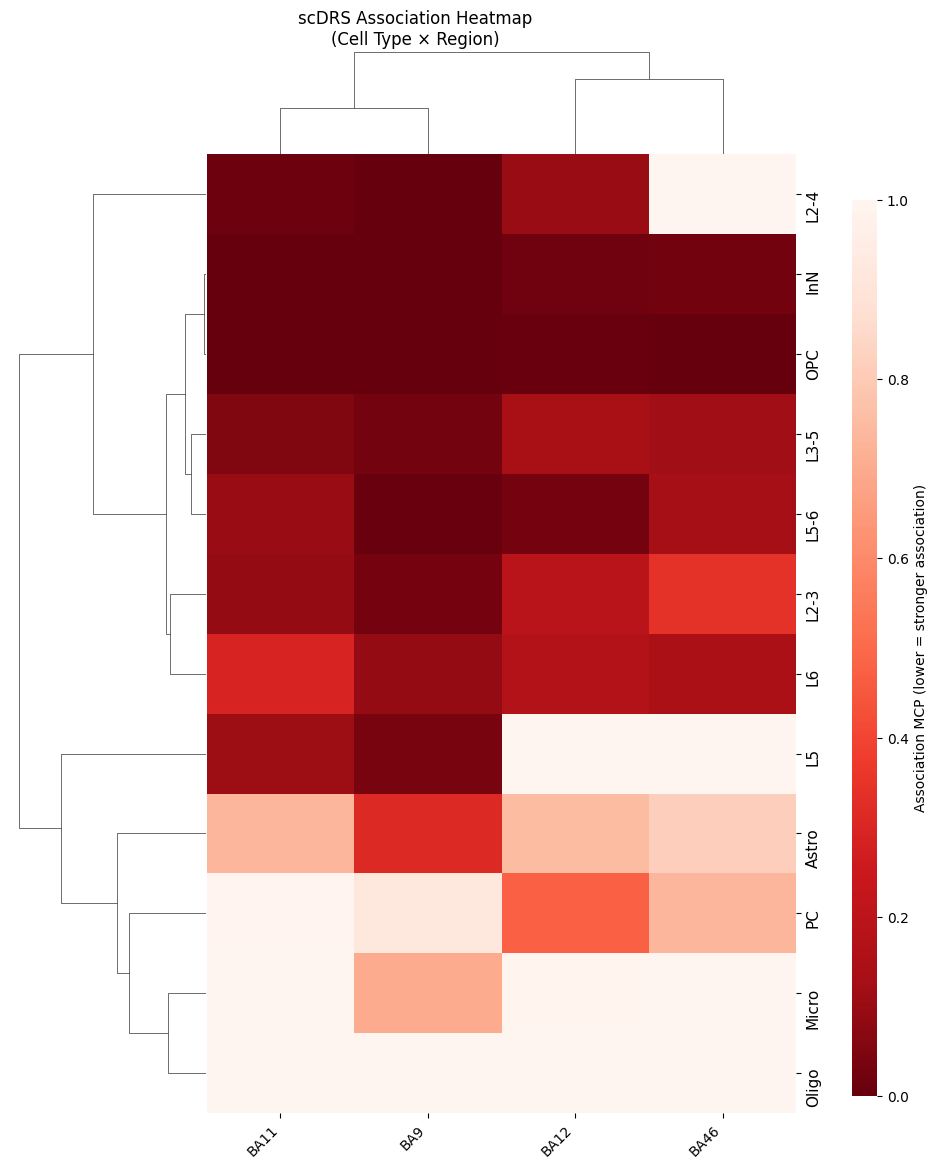

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取数据
df = pd.read_csv(
    "mdd3_analysis/mdd.scdrs_group.BA_dominantshort",
    sep="\t"
)

# 2. 解析 group 列，拆分出 region 和 celltype
df["region"] = df["group"].str.split("&").str[0]
df["celltype"] = df["group"].str.split("&").str[1]

# 检查是否有无法解析的行
if df["celltype"].isna().any():
    print("存在无法解析的 group 行，已剔除")
    df = df[~df["celltype"].isna()]

# 3. 提取唯一脑区和细胞类型
regions = sorted(df["region"].unique())
celltypes = sorted(df["celltype"].unique())

# 4. 创建矩阵 (行=celltype, 列=region)
assoc_matrix = np.full((len(celltypes), len(regions)), np.nan)

# 5. 填充矩阵
for idx, row in df.iterrows():
    i = celltypes.index(row["celltype"])
    j = regions.index(row["region"])
    assoc_matrix[i, j] = row["assoc_mcp"]

# 6. 转为 DataFrame，方便 clustermap
df_assoc = pd.DataFrame(
    assoc_matrix,
    index=celltypes,
    columns=regions
)

# 7. 检查并处理 NaN / inf
df_assoc = df_assoc.replace([np.inf, -np.inf], np.nan)  # 先把 inf 转成 NaN
df_assoc = df_assoc.fillna(1.0)  # 用 1.0 填充 NaN（最弱关联）
# 你也可以选择 fillna(0.5) 或者 df_assoc.mean().mean()

# 8. 聚类热图
g = sns.clustermap(
    df_assoc,
    cmap="Reds_r",
    vmin=0,
    vmax=1,
    figsize=(len(regions)*0.6+6, len(celltypes)*0.6+4),
    row_cluster=True,   # 对 celltype 聚类
    col_cluster=True,   # 对 region 聚类
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.25, 0.1),
    cbar_pos=(1.02, 0.05, 0.03, 0.8),  # 调整色条位置
    cbar_kws={"label": "Association MCP (lower = stronger association)"}
)

# 9. 标题
g.fig.suptitle(
    "scDRS Association Heatmap\n(Cell Type × Region)",
    fontsize=12,
    y=1.02
)

# 10. 美化标签
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=10
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=11
)

# 11. 保存和展示
g.savefig("20250930mdd3-figures/4.1ct×section_merged_heatmap_MDD_with_significance.pdf", dpi=300, format='pdf')
plt.show()


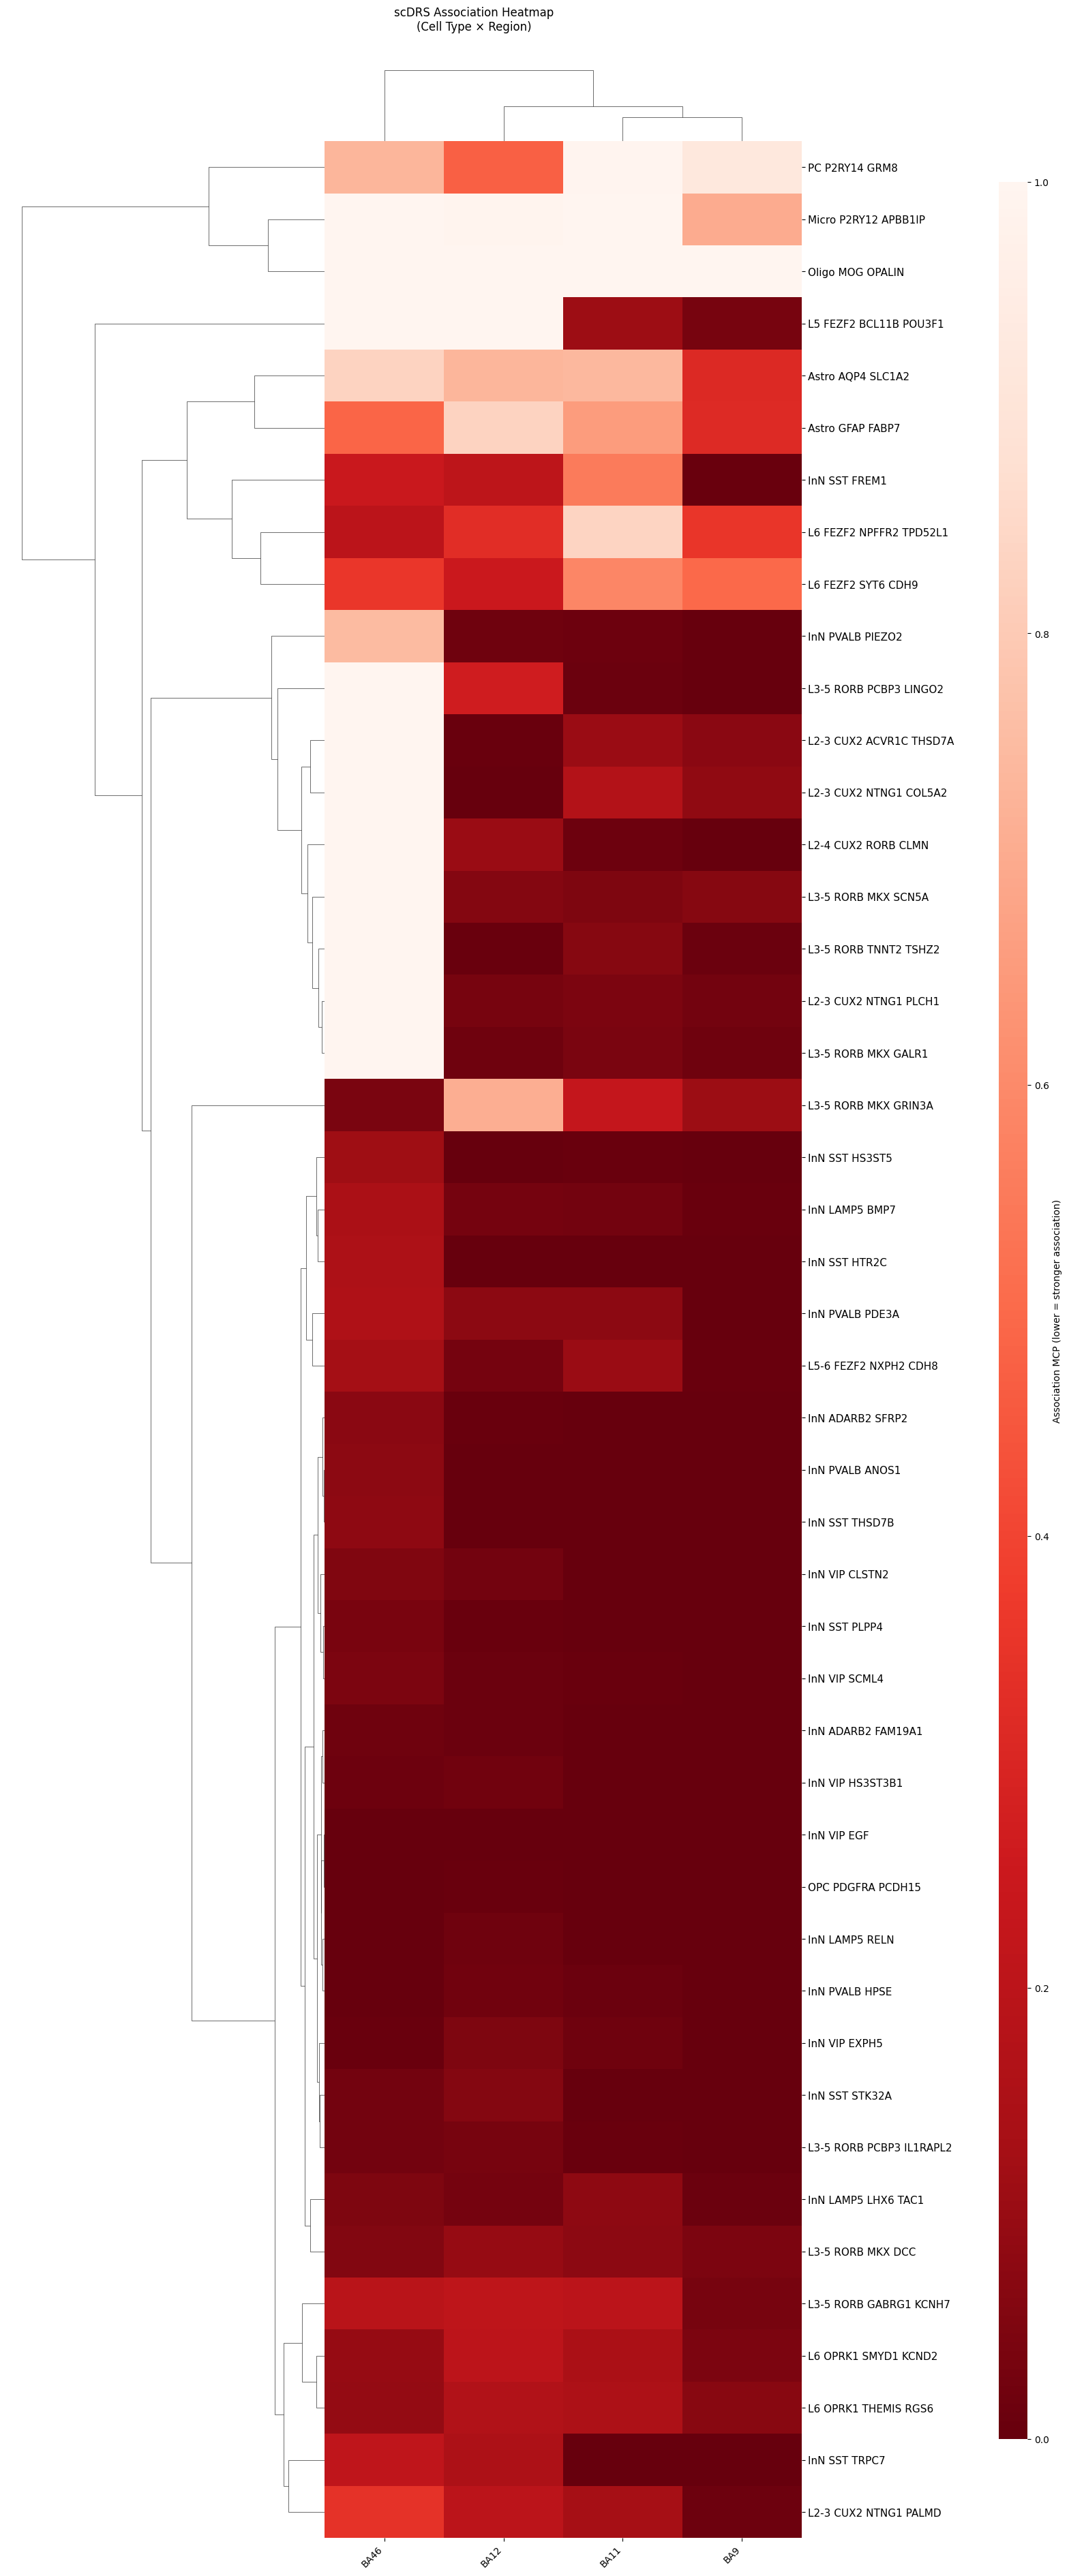

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取数据
df = pd.read_csv(
    "mdd3_analysis/mdd.scdrs_group.BA_celltype",
    sep="\t"
)

# 2. 解析 group 列，拆分出 region 和 celltype
df["region"] = df["group"].str.split("&").str[0]
df["celltype"] = df["group"].str.split("&").str[1]

# 检查是否有无法解析的行
if df["celltype"].isna().any():
    print("存在无法解析的 group 行，已剔除")
    df = df[~df["celltype"].isna()]

# 3. 提取唯一脑区和细胞类型
regions = sorted(df["region"].unique())
celltypes = sorted(df["celltype"].unique())

# 4. 创建矩阵 (行=celltype, 列=region)
assoc_matrix = np.full((len(celltypes), len(regions)), np.nan)

# 5. 填充矩阵
for idx, row in df.iterrows():
    i = celltypes.index(row["celltype"])
    j = regions.index(row["region"])
    assoc_matrix[i, j] = row["assoc_mcp"]

# 6. 转为 DataFrame，方便 clustermap
df_assoc = pd.DataFrame(
    assoc_matrix,
    index=celltypes,
    columns=regions
)

# 7. 检查并处理 NaN / inf
df_assoc = df_assoc.replace([np.inf, -np.inf], np.nan)  # 先把 inf 转成 NaN
df_assoc = df_assoc.fillna(1.0)  # 用 1.0 填充 NaN（最弱关联）

# 8. 聚类热图
g = sns.clustermap(
    df_assoc,
    cmap="Reds_r",
    vmin=0,
    vmax=1,
    figsize=(len(regions)*1+10, len(celltypes)*0.8),
    row_cluster=True,   # 对 celltype 聚类
    col_cluster=True,   # 对 region 聚类
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.4, 0.03),
    cbar_pos=(1.05, 0.05, 0.03, 0.9),  # 调整色条位置
    cbar_kws={"label": "Association MCP (lower = stronger association)"}
)

# 9. 标题
g.fig.suptitle(
    "scDRS Association Heatmap\n(Cell Type × Region)",
    fontsize=12,
    y=1.02
)


# 10. 美化标签
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=10
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=11
)

# 11. 保存和展示
g.savefig("20250930mdd3-figures/4.2ct×section_merged_heatmap_MDD_with_significance.pdf", dpi=300, format='pdf')
plt.show()


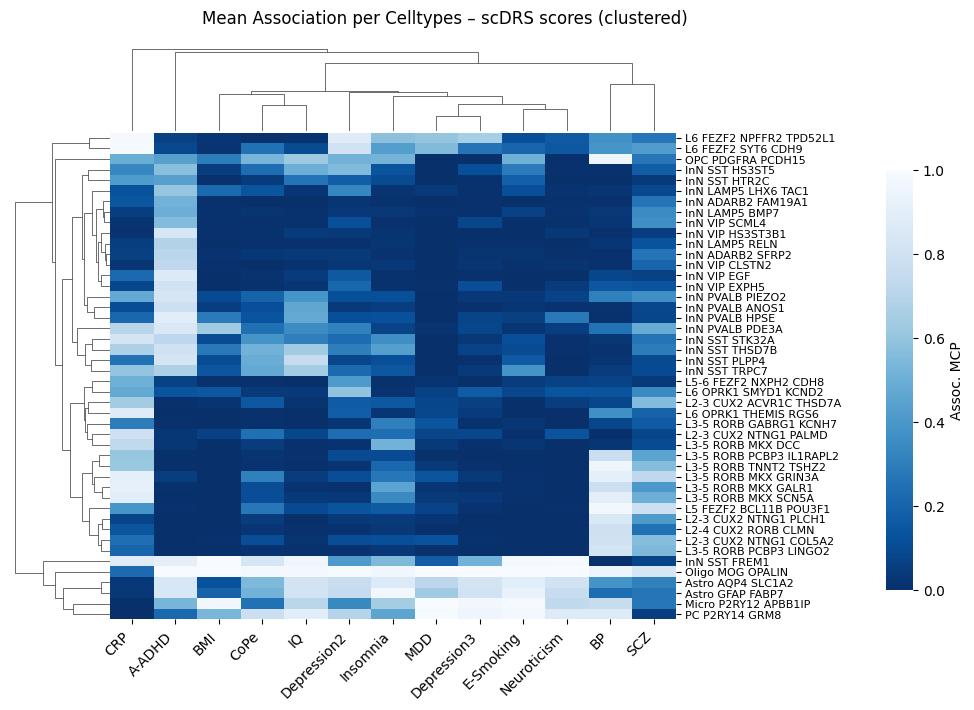

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

traits = ['mdd','A-ADHD', 'BMI', 'BP', 'CRP', 'CoPe', 'Depression2', 'E-Smoking', 'IQ', 'Insomnia', 'Neuroticism', 'SCZ', 'Depression3']
traits_names = ['MDD','A-ADHD', 'BMI', 'BP', 'CRP', 'CoPe', 'Depression2', 'E-Smoking', 'IQ', 'Insomnia', 'Neuroticism', 'SCZ', 'Depression3']

# 创建名称映射字典
name_mapping = dict(zip(traits, traits_names))

# 读取数据
dict_df_stats = {
    trait: pd.read_csv(
        f"alltrait_analysis/downstream/{trait}.scdrs_group.dominant_labels",
        sep="\t",
        index_col=0
    )
    for trait in traits
}

# 样本名称
samples = list(dict_df_stats[traits[0]].index)

# 创建assoc_mcp矩阵
assoc_matrix = np.array([
    dict_df_stats[trait].loc[samples, "assoc_mcp"].values
    for trait in traits
]).T

# 创建 DataFrame
df_assoc = pd.DataFrame(assoc_matrix, index=samples, columns=traits)

g = sns.clustermap(
    df_assoc,
    cmap="Blues_r",
    vmin=0,
    vmax=1,
    figsize=(9, 7),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.99, 0.2, 0.03, 0.6),
    cbar_kws={"label": "Assoc. MCP", "shrink": 0.5}
)

# 获取聚类后的列顺序
clustered_columns = g.data2d.columns  # 这是聚类后的列顺序

# 使用映射字典获取对应的显示名称
clustered_trait_names = [name_mapping[col] for col in clustered_columns]

# 设置主标题
g.fig.suptitle(
    "Mean Association per Celltypes – scDRS scores (clustered)",
    fontsize=12,
    y=1.03
)

heatmap_ax = g.ax_heatmap

# 设置正确的标签顺序
heatmap_ax.set_xticklabels(
    clustered_trait_names,  # 使用聚类后的名称顺序
    rotation=45,
    ha="right",
    fontsize=10
)

heatmap_ax.set_yticklabels(
    heatmap_ax.get_yticklabels(), 
    fontsize=8 
)

#plt.tight_layout()
g.savefig("20250930mdd3-figures/6.1traits×ct_scDRS_MDD_GWAS_Association_Heatmap_CLUSTERED_v4.pdf", dpi=300, format='pdf')
plt.show()

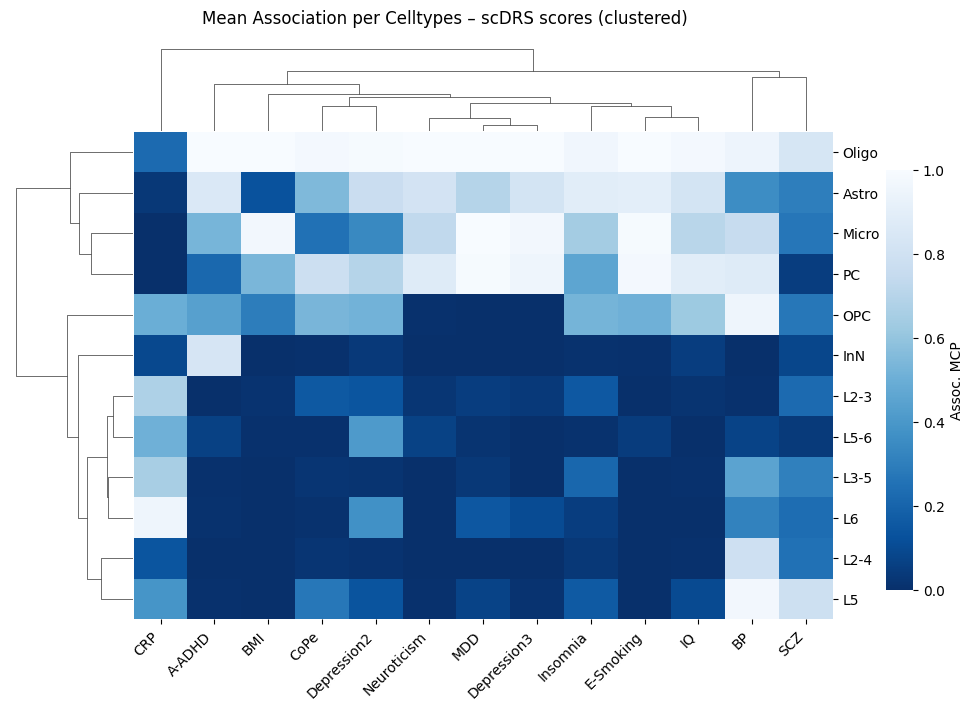

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

traits = ['mdd','A-ADHD', 'BMI', 'BP', 'CRP', 'CoPe', 'Depression2', 'E-Smoking', 'IQ', 'Insomnia', 'Neuroticism', 'SCZ', 'Depression3']
#traits = ['mdd', 'BP',  'CoPe', 'Depression2',  'Insomnia', 'Neuroticism', 'SCZ']
#trait_names=['MDD-Andrew M. et al. cell 2025', 'BP-Mullins et al. Nat Genetc 2021',  'CoPe-Lee et al. Nat Genet 2018', 'Depression-a -Howard et al. Nat Commun 2018',  'Insomnia-Philip Jansen et al. Nat Genet 2019', 'Neuroticism-Mats Nagel et al. Nat Genet 2018', 'SCZ-Trubetskoy et al. Nature 2022']
# 读取数据
dict_df_stats = {
    trait: pd.read_csv(
        f"alltrait_analysis/downstream/{trait}.scdrs_group.dominant_labels_short",
        sep="\t",
        index_col=0
    )
    for trait in traits
}

# 样本名称
samples = list(dict_df_stats[traits[0]].index)

# 创建assoc_mcp矩阵
assoc_matrix = np.array([
    dict_df_stats[trait].loc[samples, "assoc_mcp"].values
    for trait in traits
]).T


# 创建 DataFrame
df_assoc = pd.DataFrame(assoc_matrix, index=samples, columns=traits)

# 新标签
traits_names = ['MDD','A-ADHD', 'BMI', 'BP', 'CRP', 'CoPe', 
                'Depression2', 'E-Smoking', 'IQ', 'Insomnia', 'Neuroticism', 'SCZ', 'Depression3']

# 画图
g = sns.clustermap(
    df_assoc,
    cmap="Blues_r",
    vmin=0,
    vmax=1,
    figsize=(9, 7),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.99, 0.2, 0.03, 0.6),
    cbar_kws={"label": "Assoc. MCP", "shrink": 0.5}
)

# 设置主标题
g.fig.suptitle(
    "Mean Association per Celltypes – scDRS scores (clustered)",
    fontsize=12,
    y=1.03
)

# 获取热图的 Axes 对象
heatmap_ax = g.ax_heatmap  

# 设置 Y 轴标签字体大小
heatmap_ax.set_yticklabels(
    heatmap_ax.get_yticklabels(), 
    fontsize=10 
)

# 替换 X 轴的标签（按照 clustermap 聚类后的顺序来重新映射）
new_labels = [traits_names[df_assoc.columns.get_loc(col.get_text())] 
              for col in heatmap_ax.get_xticklabels()]

heatmap_ax.set_xticklabels(
    new_labels,
    rotation=45,
    ha="right",
    fontsize=10
)

# 保存
g.savefig("20250930mdd3-figures/6.2traits×ct_scDRS_MDD_GWAS_Association_Heatmap_CLUSTERED_v4.pdf", dpi=300, format='pdf')
plt.show()



In [8]:
#计算目的性状的λGC值
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os, glob
from scipy.stats import chi2

# ==== λGC计算函数 ====
def calc_lambda_gc(pvals):
    pvals = pvals.dropna()
    pvals = pvals[pvals > 0]
    chisq = chi2.isf(pvals, 1)
    return np.median(chisq) / 0.4549

# ==== 主程序 ====
input_dir = "/biostack/home/suchenyi/scdrs/GWAS/"
file_list = [
    "trait_Depression.tsv",
    "trait_BP.tsv",
    "trait_SCZ.tsv",
    "trait_Neuroticism.tsv",
    "trait_Insomnia.tsv",
    "trait_CoPe.tsv",
    "trait_MDD.tsv"
]

results = []

print("========== λGC 计算结果 ==========")
for file in file_list:
    path = os.path.join(input_dir, file)
    if not os.path.exists(path):
        print(f"文件不存在: {path}")
        continue
    
    df = pd.read_csv(path, sep="\t")
    if 'P' not in df.columns:
        print(f"文件 {file} 缺少 P 值列！")
        continue
    
    pvals = df['P']
    n_total = len(pvals)
    lambda_gc = calc_lambda_gc(pvals)
    lambda_gc_bg = calc_lambda_gc(pvals[pvals > 1e-5])
    results.append({
        "Trait": file.replace("trait_", "").replace(".tsv", ""),
        "N_SNP": n_total,
        "Lambda_GC": lambda_gc,
        "Lambda_GC_bg": lambda_gc_bg
    })
    
    print(f"{file:<30}  λGC = {lambda_gc:.4f}  (背景λGC = {lambda_gc_bg:.4f})")

print("=================================\n")

# ==== 结果汇总表 ====
df_res = pd.DataFrame(results)
df_res.to_csv("lambda_GC_summary.tsv", sep="\t", index=False)
print("结果已保存: lambda_GC_summary.tsv")

# ==== 绘制柱状图 ====
plt.figure(figsize=(8,5))
plt.bar(df_res["Trait"], df_res["Lambda_GC"], color="#4C72B0", alpha=0.8, label="总体 λGC")
plt.bar(df_res["Trait"], df_res["Lambda_GC_bg"], color="#55A868", alpha=0.7, label="背景 λGC (p>1e-5)")
plt.ylabel("λGC", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.title("Genome Inflation Factor (λGC) Across GWAS Traits")
plt.legend()
plt.tight_layout()
plt.savefig("lambda_GC_barplot.png", dpi=300)
plt.close()

print("柱状图已保存: lambda_GC_barplot.png")


========== λGC 计算结果 ==========
trait_Depression.tsv            λGC = 1.3859  (背景λGC = 1.3805)
trait_BP.tsv                    λGC = 1.3769  (背景λGC = 1.3715)
trait_SCZ.tsv                   λGC = 1.6148  (背景λGC = 1.5918)


/tmp/ipykernel_108772/2092074792.py:36: DtypeWarning: Columns (0,1,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep="\t")


trait_Neuroticism.tsv           λGC = 1.3380  (背景λGC = 1.3292)


/tmp/ipykernel_108772/2092074792.py:36: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep="\t")


trait_Insomnia.tsv              λGC = 1.1688  (背景λGC = 1.1683)
trait_CoPe.tsv                  λGC = 1.4051  (背景λGC = 1.3871)
trait_MDD.tsv                   λGC = 1.7882  (背景λGC = 1.7564)

✅ 结果已保存: lambda_GC_summary.tsv


/tmp/ipykernel_108772/2092074792.py:69: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108772/2092074792.py:69: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108772/2092074792.py:69: UserWarning: Glyph 32972 (\N{CJK UNIFIED IDEOGRAPH-80CC}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108772/2092074792.py:69: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_108772/2092074792.py:70: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from current font.
  plt.savefig("lambda_GC_barplot.png", dpi=300)
/tmp/ipykernel_108772/2092074792.py:70: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from current font.
  plt.savefig("lambda_GC_barplot.png", dpi=300)
/tmp/ipykernel_108772/2092074792.py:70: UserWarning: Glyph 32972 (\N{C

✅ 柱状图已保存: lambda_GC_barplot.png


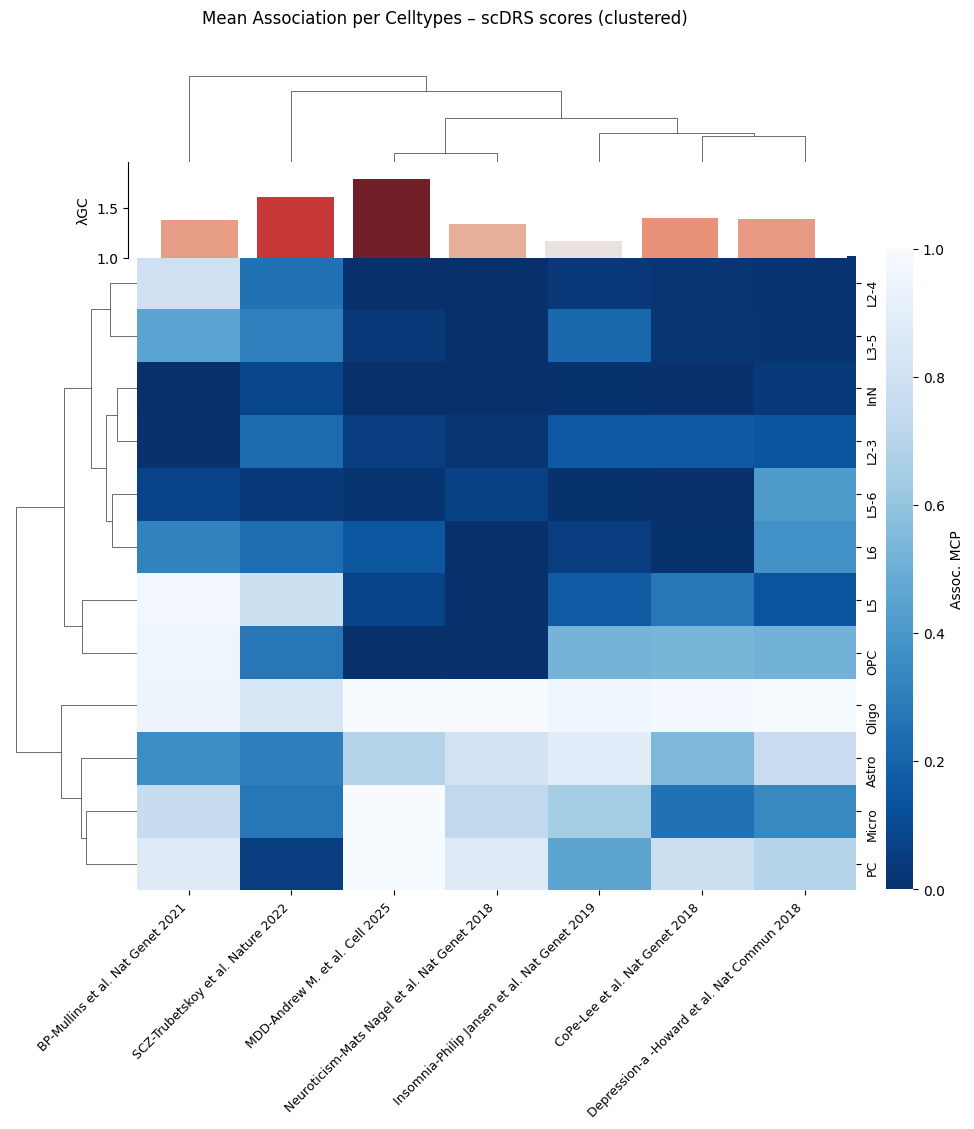

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === 基础参数 ===
traits = ['mdd', 'BP', 'CoPe', 'Depression2', 'Insomnia', 'Neuroticism', 'SCZ']
traits_names = [
    'MDD-Andrew M. et al. Cell 2025',
    'BP-Mullins et al. Nat Genet 2021',
    'CoPe-Lee et al. Nat Genet 2018',
    'Depression-a -Howard et al. Nat Commun 2018',
    'Insomnia-Philip Jansen et al. Nat Genet 2019',
    'Neuroticism-Mats Nagel et al. Nat Genet 2018',
    'SCZ-Trubetskoy et al. Nature 2022'
]

# === 读取scDRS结果 ===
dict_df_stats = {
    trait: pd.read_csv(
        f"alltrait_analysis/downstream/{trait}.scdrs_group.dominant_labels_short",
        sep="\t", index_col=0
    )
    for trait in traits
}

samples = list(dict_df_stats[traits[0]].index)
assoc_matrix = np.array([
    dict_df_stats[trait].loc[samples, "assoc_mcp"].values
    for trait in traits
]).T
df_assoc = pd.DataFrame(assoc_matrix, index=samples, columns=traits)

# === 读取λGC文件 ===
df_gc = pd.read_csv("lambda_GC_summary.tsv", sep="\t")
name_map = {
    'Depression2': 'Depression',
    'mdd': 'MDD',
    'BP': 'BP',
    'CoPe': 'CoPe',
    'Insomnia': 'Insomnia',
    'Neuroticism': 'Neuroticism',
    'SCZ': 'SCZ'
}

df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")
lambda_gc_values = []
for t in traits:
    name_in_gc = name_map.get(t, t)
    if name_in_gc in df_gc.index:
        lambda_gc_values.append(df_gc.loc[name_in_gc, "Lambda_GC"])
    else:
        lambda_gc_values.append(np.nan)
lambda_gc_values = np.array(lambda_gc_values, dtype=float)
lambda_gc_values = np.nan_to_num(lambda_gc_values, nan=1.0, posinf=1.0, neginf=1.0)

# === 绘制热图 ===
g = sns.clustermap(
    df_assoc,
    cmap="Blues_r",
    vmin=0, vmax=1,
    figsize=(9, 8),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.99, 0.05, 0.03, 0.8),
    cbar_kws={"label": "Assoc. MCP", "shrink": 0.5}
)

# 获取聚类顺序
col_order = g.dendrogram_col.reordered_ind
ordered_traits = [df_assoc.columns[i] for i in col_order]
ordered_trait_labels = [traits_names[traits.index(t)] for t in ordered_traits]
ordered_gc = [lambda_gc_values[traits.index(t)] for t in ordered_traits]

# === 调整列聚类树位置，向上腾出空间放柱状图 ===
col_dendro_ax = g.ax_col_dendrogram
pos = col_dendro_ax.get_position()
new_height = pos.height * 0.95  # 缩短 dendrogram 高度
new_y = pos.y0 + pos.height * 0.7  # 上移 dendrogram
col_dendro_ax.set_position([pos.x0, new_y, pos.width, new_height])

# === 绘制顶部 λGC 柱状图 ===
bar_ax = g.fig.add_axes([
    pos.x0-0.01,                # 与 dendrogram 左对齐
    new_y - 0.1,          # 放在 dendrogram 下方、热图上方
    pos.width,
    0.12                   # 柱状图高度
])
bar_ax.bar(range(len(ordered_traits)), ordered_gc, color="gray", alpha=0.8)
bar_ax.set_xticks(range(len(ordered_traits)))
bar_ax.set_xticklabels([])
bar_ax.set_ylabel("λGC", fontsize=10)
bar_ax.set_ylim(1, np.nanmax(ordered_gc) * 1.1)
bar_ax.spines[["top", "right","bottom"]].set_visible(False)
bar_ax.tick_params(axis='x', which='both', bottom=False)
norm = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors = [cm.Reds(norm(val)) for val in ordered_gc]  # Reds colormap
bar_ax.bar(range(len(ordered_traits)), ordered_gc, color=colors, alpha=0.8, edgecolor="none")


# === 设置热图 x轴标签 ===
heatmap_ax = g.ax_heatmap
heatmap_ax.set_xticklabels(ordered_trait_labels, rotation=45, ha="right", fontsize=9)
heatmap_ax.set_yticklabels(heatmap_ax.get_yticklabels(), fontsize=9)

# 主标题
g.fig.suptitle("Mean Association per Celltypes – scDRS scores (clustered)",
               fontsize=12, y=1.15)

# 保存
g.savefig("20251022_traits×ct_scDRS_MDD_GWAS_Association_Heatmap_with_LambdaGC_v4.pdf", dpi=300)
plt.show()


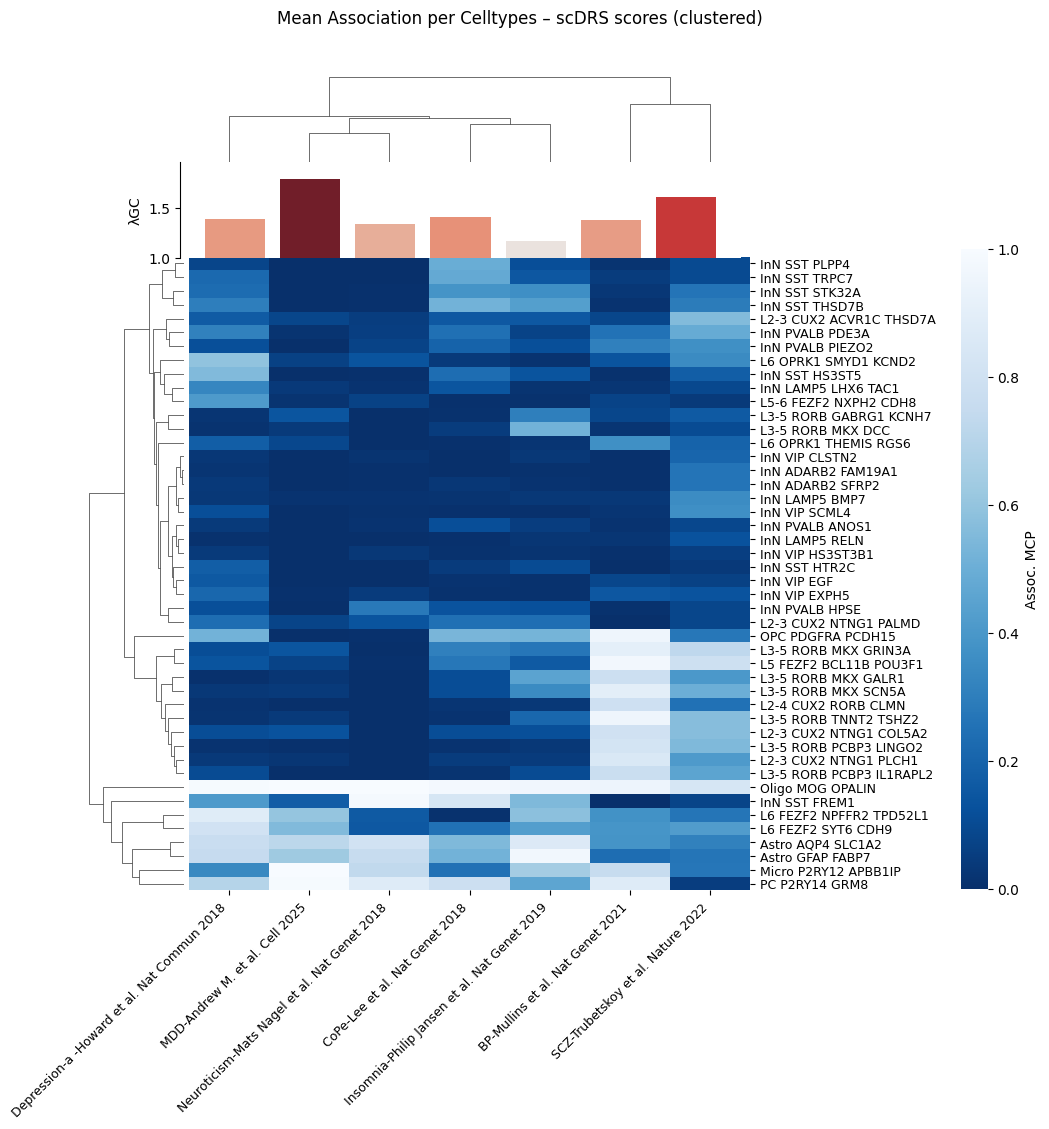

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === 基础参数 ===
traits = ['mdd', 'BP', 'CoPe', 'Depression2', 'Insomnia', 'Neuroticism', 'SCZ']
traits_names = [
    'MDD-Andrew M. et al. Cell 2025',
    'BP-Mullins et al. Nat Genet 2021',
    'CoPe-Lee et al. Nat Genet 2018',
    'Depression-a -Howard et al. Nat Commun 2018',
    'Insomnia-Philip Jansen et al. Nat Genet 2019',
    'Neuroticism-Mats Nagel et al. Nat Genet 2018',
    'SCZ-Trubetskoy et al. Nature 2022'
]

# === 读取scDRS结果 ===
dict_df_stats = {
    trait: pd.read_csv(
        f"alltrait_analysis/downstream/{trait}.scdrs_group.dominant_labels",
        sep="\t", index_col=0
    )
    for trait in traits
}

samples = list(dict_df_stats[traits[0]].index)
assoc_matrix = np.array([
    dict_df_stats[trait].loc[samples, "assoc_mcp"].values
    for trait in traits
]).T
df_assoc = pd.DataFrame(assoc_matrix, index=samples, columns=traits)

# === 读取λGC文件 ===
df_gc = pd.read_csv("lambda_GC_summary.tsv", sep="\t")
name_map = {
    'Depression2': 'Depression',
    'mdd': 'MDD',
    'BP': 'BP',
    'CoPe': 'CoPe',
    'Insomnia': 'Insomnia',
    'Neuroticism': 'Neuroticism',
    'SCZ': 'SCZ'
}

df_gc["Trait"] = df_gc["Trait"].astype(str)
df_gc = df_gc.set_index("Trait")
lambda_gc_values = []
for t in traits:
    name_in_gc = name_map.get(t, t)
    if name_in_gc in df_gc.index:
        lambda_gc_values.append(df_gc.loc[name_in_gc, "Lambda_GC"])
    else:
        lambda_gc_values.append(np.nan)
lambda_gc_values = np.array(lambda_gc_values, dtype=float)
lambda_gc_values = np.nan_to_num(lambda_gc_values, nan=1.0, posinf=1.0, neginf=1.0)

# === 绘制热图 ===
g = sns.clustermap(
    df_assoc,
    cmap="Blues_r",
    vmin=0, vmax=1,
    figsize=(9, 8),
    row_cluster=True,
    col_cluster=True,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.99, 0.05, 0.03, 0.8),
    cbar_kws={"label": "Assoc. MCP", "shrink": 0.5}
)

# 获取聚类顺序
col_order = g.dendrogram_col.reordered_ind
ordered_traits = [df_assoc.columns[i] for i in col_order]
ordered_trait_labels = [traits_names[traits.index(t)] for t in ordered_traits]
ordered_gc = [lambda_gc_values[traits.index(t)] for t in ordered_traits]

# === 调整列聚类树位置，向上腾出空间放柱状图 ===
col_dendro_ax = g.ax_col_dendrogram
pos = col_dendro_ax.get_position()
new_height = pos.height * 0.95  # 缩短 dendrogram 高度
new_y = pos.y0 + pos.height * 0.7  # 上移 dendrogram
col_dendro_ax.set_position([pos.x0, new_y, pos.width, new_height])

# === 绘制顶部 λGC 柱状图 ===
bar_ax = g.fig.add_axes([
    pos.x0-0.01,                # 与 dendrogram 左对齐
    new_y - 0.1,          # 放在 dendrogram 下方、热图上方
    pos.width,
    0.12                   # 柱状图高度
])
bar_ax.bar(range(len(ordered_traits)), ordered_gc, color="gray", alpha=0.8)
bar_ax.set_xticks(range(len(ordered_traits)))
bar_ax.set_xticklabels([])
bar_ax.set_ylabel("λGC", fontsize=10)
bar_ax.set_ylim(1, np.nanmax(ordered_gc) * 1.1)
bar_ax.spines[["top", "right","bottom"]].set_visible(False)
bar_ax.tick_params(axis='x', which='both', bottom=False)
norm = mcolors.Normalize(vmin=min(ordered_gc), vmax=max(ordered_gc))
colors = [cm.Reds(norm(val)) for val in ordered_gc]  # Reds colormap
bar_ax.bar(range(len(ordered_traits)), ordered_gc, color=colors, alpha=0.8, edgecolor="none")


# === 设置热图 x轴标签 ===
heatmap_ax = g.ax_heatmap
heatmap_ax.set_xticklabels(ordered_trait_labels, rotation=45, ha="right", fontsize=9)
heatmap_ax.set_yticklabels(heatmap_ax.get_yticklabels(), fontsize=9)

# 主标题
g.fig.suptitle("Mean Association per Celltypes – scDRS scores (clustered)",
               fontsize=12, y=1.15)

# 保存
g.savefig("20251022.2_traits×ct_scDRS_MDD_GWAS_Association_Heatmap_with_LambdaGC_v4.pdf", dpi=300)
plt.show()
